In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import os
import re
import random

import torch
import optuna
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.manifold import TSNE
from scipy import stats

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Теперь возьмём какой-то срез из данных (по кол-ву строк):

In [ ]:
N_ROWS = 100_000_000  # использовали, чтобы замерить время импорта данных
    
start_time = time.time()
data = pd.read_csv("../data/events.csv")
end_time = time.time()

print(f"Время: {end_time - start_time:.2f} секунд")


Время: 361.87 секунд


Как выглядит сырой набор событий:

In [10]:
data

,appmetrica_device_id,event_name,event_json,event_datetime,event_timestamp,session_id
0,6997871487008262307,BOOT_TIME,"{""Startup"":{""index"":""1"",""elapsed"":""0,000"",""tot...",2026-03-13 22:24:21,1773426261,10000000003
1,6997871487008262307,BOOT_TIME,"{""Modules initialization started"":{""index"":""2""...",2026-03-13 22:24:21,1773426261,10000000003
2,6997871487008262307,BOOT_TIME,"{""Modules initialization finished"":{""index"":""3...",2026-03-13 22:24:21,1773426261,10000000003
3,6997871487008262307,BOOT_TIME,"{""Game node register repositories"":{""index"":""4...",2026-03-13 22:24:21,1773426261,10000000003
4,6997871487008262307,BOOT_TIME,"{""Load game data started"":{""index"":""5"",""elapse...",2026-03-13 22:24:21,1773426261,10000000003
...,...,...,...,...,...,...
73063797,18053556893490936191,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-01 09:11:01,1772341861,10000000060
73063798,18053556893490936191,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-01 09:12:01,1772341921,10000000060
73063799,18053556893490936191,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-01 09:13:01,1772341981,10000000060
73063800,18141263714225775897,machine_learning,"{""init_event"":{""session_cnt"":""1"",""avg_playtime...",2026-03-01 13:15:54,1772356554,10000000001


Преобразуем столбец `event_datetime`, чтобы далее использовать модуль `datetime` для обработки данных:

In [11]:
data['event_datetime'] = pd.to_datetime(data['event_datetime'])
data

,appmetrica_device_id,event_name,event_json,event_datetime,event_timestamp,session_id
0,6997871487008262307,BOOT_TIME,"{""Startup"":{""index"":""1"",""elapsed"":""0,000"",""tot...",2026-03-13 22:24:21,1773426261,10000000003
1,6997871487008262307,BOOT_TIME,"{""Modules initialization started"":{""index"":""2""...",2026-03-13 22:24:21,1773426261,10000000003
2,6997871487008262307,BOOT_TIME,"{""Modules initialization finished"":{""index"":""3...",2026-03-13 22:24:21,1773426261,10000000003
3,6997871487008262307,BOOT_TIME,"{""Game node register repositories"":{""index"":""4...",2026-03-13 22:24:21,1773426261,10000000003
4,6997871487008262307,BOOT_TIME,"{""Load game data started"":{""index"":""5"",""elapse...",2026-03-13 22:24:21,1773426261,10000000003
...,...,...,...,...,...,...
73063797,18053556893490936191,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-01 09:11:01,1772341861,10000000060
73063798,18053556893490936191,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-01 09:12:01,1772341921,10000000060
73063799,18053556893490936191,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-01 09:13:01,1772341981,10000000060
73063800,18141263714225775897,machine_learning,"{""init_event"":{""session_cnt"":""1"",""avg_playtime...",2026-03-01 13:15:54,1772356554,10000000001


In [12]:
# Получаем самую старую и новую дату
oldest_date = data['event_datetime'].min()
newest_date = data['event_datetime'].max()

print(f"Самая старая дата: {oldest_date}")
print(f"Самая новая дата: {newest_date}")

Самая старая дата: 2026-02-27 00:00:00
Самая новая дата: 2026-03-29 23:53:27


In [13]:
unique_users_id = data['appmetrica_device_id'].unique()
print("Число уникальных пользователей в датасете:", len(unique_users_id))

Число уникальных пользователей в датасете: 68544


In [14]:
unique_events = data['event_name'].value_counts()

print(f"Число уникальных типов событий: {len(unique_events)}")

unique_events.to_dict()

Число уникальных типов событий: 94


{'REWARD': 12722794,
 'BOOT_TIME': 9737307,
 'machine_learning': 7670256,
 'Training': 7218253,
 'PlayTimeMinutes': 4708365,
 'Equipment levels': 4401100,
 'Coffee': 4247142,
 'Equipment merges': 3886138,
 'itemsDropEmission': 1906584,
 'CohortData': 1501524,
 'Gun Store': 1334316,
 'GameData': 1327992,
 'Replay': 1254860,
 'Mount Garage': 872064,
 'ADS': 799061,
 'Woodmill': 671408,
 'AB failed to initialize': 569979,
 'AB': 548979,
 'Boss': 546817,
 'BOOT_TIME_SECONDS': 507942,
 'Apples': 496532,
 'SystemInitialized': 495733,
 'Quests': 457253,
 'PlayTimeAfkMinutes': 423069,
 'DebugAdEvents': 381918,
 'PlayTimeSeconds': 377607,
 'Garage': 348689,
 'Workshop': 289695,
 'SystemInitializing': 253042,
 'Game loaded': 250629,
 'Tools': 249925,
 'Lab dungeon': 201498,
 'Plant': 197460,
 'Chemicals': 176058,
 'Gate': 169488,
 'Meds': 159443,
 'Store': 151174,
 'Windmill': 145442,
 'Pizza': 132591,
 'Heist': 125659,
 'Bakery': 119454,
 'Suburb_Woodmill': 99844,
 'ad_reward_optimization_error

Здесь покажем, как мы вытаскиваем фичи, которые будем использовать/модифицировать для обучения модели:

```python
# Разделять пользователей по appmetrica_device_id и применять фильтр к каждому пользователю:

def get_features_per_user(appmetrica_id, data_id):
    # код для получения признаков для одного пользователя ...
    pass

train_data = pd.DataFrame() 

for i, (user, group) in enumerate(grouped):
    features = get_features_per_user(user, group)
    train_data = pd.concat([train_data, features], ignore_index=True)
```

Для понимания, посмотрим, как выглядят данные для каждого пользователя:

In [15]:
grouped = data.groupby('appmetrica_device_id')

for i, (user, group) in enumerate(grouped):
    if i >= 3:
        break
    print(f"Пользователь {user}:")
    display(group)
    print(type(user), type(group), '\n')

Пользователь 79991494175977:


,appmetrica_device_id,event_name,event_json,event_datetime,event_timestamp,session_id
66521467,79991494175977,AB,"{""WithAdRewardOptimization"":""AB_B_0""}",2026-03-28 20:20:23,1774714823,10000000001
66521468,79991494175977,AB,"{""WithAdRewardMultiplier"":""B_B_0""}",2026-03-28 20:20:23,1774714823,10000000001
66521469,79991494175977,AB,"{""WithLootCase"":""C_C_0""}",2026-03-28 20:20:23,1774714823,10000000001
66521470,79991494175977,AB,"{""WithNewBalance"":""A_A_0""}",2026-03-28 20:20:23,1774714823,10000000001
66521471,79991494175977,AB,"{""WithBikeBlackMarket"":""A_A_0""}",2026-03-28 20:20:23,1774714823,10000000001
...,...,...,...,...,...,...
66534478,79991494175977,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-28 20:31:24,1774715484,10000000001
66534479,79991494175977,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-28 20:31:39,1774715499,10000000001
66534480,79991494175977,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-28 20:32:39,1774715559,10000000001
66534481,79991494175977,machine_learning,"{""user_snapshot_active_state"":{""game_minute"":""...",2026-03-28 20:33:39,1774715619,10000000001


<class 'int'> <class 'pandas.core.frame.DataFrame'> 

Пользователь 171820594152412:


,appmetrica_device_id,event_name,event_json,event_datetime,event_timestamp,session_id
62261576,171820594152412,AB,"{""WithAdRewardOptimization"":""AB_A_0""}",2026-03-28 14:29:38,1774693778,10000000002
62261577,171820594152412,AB,"{""WithAdRewardMultiplier"":""B_B_0""}",2026-03-28 14:29:38,1774693778,10000000002
62261578,171820594152412,AB,"{""WithLootCase"":""C_C_0""}",2026-03-28 14:29:38,1774693778,10000000002
62261579,171820594152412,AB,"{""WithNewBalance"":""A_A_0""}",2026-03-28 14:29:38,1774693778,10000000002
62261580,171820594152412,AB,"{""WithBikeBlackMarket"":""A_A_0""}",2026-03-28 14:29:38,1774693778,10000000002
...,...,...,...,...,...,...
62264577,171820594152412,Training,"{""Heath"":""1"",""PlayTimeMinutes"":""1"",""DaySinceIn...",2026-03-28 14:32:22,1774693942,10000000002
62264578,171820594152412,Training,"{""Damage"":""1"",""PlayTimeMinutes"":""1"",""DaySinceI...",2026-03-28 14:32:26,1774693946,10000000002
62264653,171820594152412,machine_learning,"{""init_event"":{""session_cnt"":""1"",""avg_playtime...",2026-03-28 14:29:42,1774693782,10000000002
62264654,171820594152412,machine_learning,"{""rewarded_ad_finished"":{""PlayTimeMinutes"":""1""...",2026-03-28 14:31:42,1774693902,10000000002


<class 'int'> <class 'pandas.core.frame.DataFrame'> 

Пользователь 243188343178703:


,appmetrica_device_id,event_name,event_json,event_datetime,event_timestamp,session_id
11877801,243188343178703,AB,"{""WithCoffeeShop"":""A_A_0""}",2026-03-08 08:30:10,1772944210,10000000001
11877802,243188343178703,AB,"{""WithMansion"":""B_B_0""}",2026-03-08 08:30:10,1772944210,10000000001
11877803,243188343178703,AB,"{""WithCutscene"":""A_A_0""}",2026-03-08 08:30:10,1772944210,10000000001
11877804,243188343178703,AB,"{""WithQuestBoard"":""A_A_0""}",2026-03-08 08:30:10,1772944210,10000000001
11880117,243188343178703,Game loaded,"{""28"":"""",""PlayTimeMinutes"":""0"",""DaySinceInstal...",2026-03-08 08:30:29,1772944229,10000000001
11886609,243188343178703,PlayTimeMinutes,"{""1"":"""",""PlayTimeMinutes"":""1"",""DaySinceInstall...",2026-03-08 08:31:29,1772944289,10000000001
11886610,243188343178703,PlayTimeMinutes,"{""2"":"""",""PlayTimeMinutes"":""2"",""DaySinceInstall...",2026-03-08 08:32:41,1772944361,10000000001
11887199,243188343178703,REWARD,"{""LOADED"":"""",""PlayTimeMinutes"":""0"",""DaySinceIn...",2026-03-08 08:30:46,1772944246,10000000001
11887200,243188343178703,REWARD,"{""ButtonShown"":""Money"",""PlayTimeMinutes"":""0"",""...",2026-03-08 08:30:59,1772944259,10000000001
11887201,243188343178703,REWARD,"{""ButtonShown"":""Money"",""PlayTimeMinutes"":""1"",""...",2026-03-08 08:31:29,1772944289,10000000001


<class 'int'> <class 'pandas.core.frame.DataFrame'> 



In [16]:
example_user_data = data[data['appmetrica_device_id'] == unique_users_id[random.randint(0, len(unique_users_id) - 1)]].reset_index(drop=True)

example_user_data

,appmetrica_device_id,event_name,event_json,event_datetime,event_timestamp,session_id
0,12714425492921994960,AB,"{""WithAdRewardMultiplier"":""B_B_0""}",2026-03-07 00:25:26,1772828726,10000000001
1,12714425492921994960,AB,"{""WithLootCase"":""C_C_0""}",2026-03-07 00:25:26,1772828726,10000000001
2,12714425492921994960,AB,"{""WithNewBalance"":""A_A_0""}",2026-03-07 00:25:26,1772828726,10000000001
3,12714425492921994960,AB,"{""WithBikeBlackMarket"":""A_A_0""}",2026-03-07 00:25:26,1772828726,10000000001
4,12714425492921994960,AB,"{""MoreGemsVipPass"":""A_A_0""}",2026-03-07 00:25:26,1772828726,10000000001
...,...,...,...,...,...,...
79,12714425492921994960,REWARD,"{""PAID"":"""",""PlayTimeMinutes"":""0"",""DaySinceInst...",2026-03-07 00:26:25,1772828785,10000000001
80,12714425492921994960,SystemInitialized,"{""AdsInitializeCommand"":""""}",2026-03-07 00:25:46,1772828746,10000000001
81,12714425492921994960,SystemInitialized,"{""CutsceneCommand"":""""}",2026-03-07 00:26:14,1772828774,10000000001
82,12714425492921994960,SystemInitializing,"{""Systems Count"":""192""}",2026-03-07 00:25:43,1772828743,10000000001


## Составление признаков

In [17]:
def count_events(data: pd.core.frame.DataFrame, event_name: str):
    """
    Считает количество событий с заданным именем event_name, появившихся у пользователя
    """

    return len(data[data['event_name'] == event_name])

# Проверка функции count_events на примере одного пользователя
for i in example_user_data['event_name'].unique():
    assert count_events(example_user_data, i) == example_user_data[example_user_data['event_name'] == i].shape[0]

In [18]:
def calc_time_in_game(data: pd.core.frame.DataFrame):
    """
    Считает время, проведенное пользователем в игре (в секундах)
    """

    data_start_event = data.groupby(["session_id"])['event_timestamp'].min().reset_index()
    data_end_event = data.groupby(["session_id"])['event_timestamp'].max().reset_index()

    duration = data_end_event['event_timestamp'] - data_start_event['event_timestamp']
    return duration.sum()

print(f"Время пользователя в игре с id {example_user_data['appmetrica_device_id'].iloc[0]}: {calc_time_in_game(example_user_data)} секунд")

Время пользователя в игре с id 12714425492921994960: 59 секунд


In [19]:
def average_session_duration(data: pd.core.frame.DataFrame):
    """
    Считает среднюю продолжительность сессии пользователя (в секундах)
    """
    data_start_event = data.groupby(["session_id"])['event_timestamp'].min().reset_index()
    data_end_event = data.groupby(["session_id"])['event_timestamp'].max().reset_index()

    duration = data_end_event['event_timestamp'] - data_start_event['event_timestamp']
    return duration.mean()

print(f"Средняя продолжительность сессии пользователя с id {example_user_data['appmetrica_device_id'].iloc[0]}: {average_session_duration(example_user_data)} секунд")

Средняя продолжительность сессии пользователя с id 12714425492921994960: 59.0 секунд


In [20]:
def first_session_duration(data: pd.core.frame.DataFrame):
    """
    Считает продолжительность первой сессии пользователя (в секундах)
    """
    data_start_event = data.groupby(["session_id"])['event_timestamp'].min().reset_index()
    data_end_event = data.groupby(["session_id"])['event_timestamp'].max().reset_index()

    duration = data_end_event['event_timestamp'] - data_start_event['event_timestamp']
    
    return duration.iloc[0]

first_session_duration(example_user_data)

np.int64(59)

In [21]:
def last_session_duration(data: pd.core.frame.DataFrame):
    """
    Считает продолжительность последней сессии пользователя (в секундах)
    """
    data_start_event = data.groupby(["session_id"])['event_timestamp'].min().reset_index()
    data_end_event = data.groupby(["session_id"])['event_timestamp'].max().reset_index()

    duration = data_end_event['event_timestamp'] - data_start_event['event_timestamp']
    
    return duration.iloc[-1]

last_session_duration(example_user_data)

np.int64(59)

In [22]:
def find_days_since_installation(data: pd.DataFrame):
    """
    Считает количество дней с момента регистрации пользователя до последнего события
    """
    last_event_date = data['event_datetime'].max()
    date_of_installation = data['event_datetime'].min()
    
    for row in data.itertuples():
        try:
            event_js = json.loads(row.event_json)
            event_date = row.event_datetime

            # Рекурсивная функция поиска DaySinceInstall
            def find_day_since_install(obj):
                if isinstance(obj, dict):
                    if 'DaySinceInstall' in obj:
                        return int(obj['DaySinceInstall'])
                    for value in obj.values():
                        result = find_day_since_install(value)
                        if result is not None:
                            return result
                return None
            
            day_since_install = find_day_since_install(event_js)
            
            if day_since_install is not None:
                candidate_install_date = event_date - pd.Timedelta(days=day_since_install)
                date_of_installation = min(date_of_installation, candidate_install_date)

        except:
            continue

    return (last_event_date - date_of_installation).days

print("Дата установки:")
print(example_user_data['event_datetime'].max() - pd.Timedelta(days=find_days_since_installation(example_user_data)))
# Проверка на сайте: https://appmetrica.yandex.ru/user-profile?group=day&appId=4507258&report=profiles-list&filters=%7B%22values%22%3A%5B%5D%7D&sampling=1&profileId=6005298646172851316&profileOriginId=0&deviceId=6005298646172851316&currency=rub&eventsSourceKind=&period=2026-03-01%3A2026-05-06&groupMethod=calendar&accuracy=medium

Дата установки:
2026-03-07 00:26:25


In [23]:
def average_interval_between_sessions(data: pd.DataFrame):
    """
    Считает среднее время интервала между сессиями (в секундах)
    """
    sessions = data.groupby('session_id')['event_datetime'].agg(['min', 'max']).sort_values('min')
    if len(sessions) < 2:
        return 0

    intervals = []
    for i in range(1, len(sessions)):
        interval = sessions.iloc[i]['min'] - sessions.iloc[i-1]['max']
        interval_seconds = interval.total_seconds()
        
        # Игнорируем отрицательные интервалы (перекрывающиеся сессии)
        if interval_seconds > 0:
            intervals.append(interval_seconds)

    return sum(intervals) / len(intervals) if intervals else 0

print(average_interval_between_sessions(example_user_data))
example_user_data.groupby('session_id')['event_datetime'].agg(['min', 'max']).sort_values('min')

0


,min,max
session_id,,
10000000001,2026-03-07 00:25:26,2026-03-07 00:26:25


In [24]:
def get_user_rating(data: pd.DataFrame):
    """
    Считает рейтинг пользователя на основе его активности.
    """
    rate_us_events = data[data['event_name'] == 'RateUs']
    
    if rate_us_events.empty:
        return None  # Для пользователей, которые не оставили рейтинг, позднее будем проставлено среднее значение рейтинга по всем пользователям.

    rate_sum, rate_count = 0, 0

    for row in rate_us_events.itertuples():
        try:
            event_js = json.loads(row.event_json)

            # Берём первый ключ, т.к. в событии 'RateUs' он соответствует рейтингу
            rating = next(iter(event_js))
            rate_sum += int(rating)
            rate_count += 1

        except (json.JSONDecodeError, ValueError, StopIteration):
            continue

    if rate_count > 0:
        return round(rate_sum / rate_count)
    else:
        return None


print(get_user_rating(example_user_data))

None


In [25]:
def max_weapon_level(data: pd.DataFrame):
    """
    Считает максимальный уровень оружия, которого достиг пользователь
    """
    max_level = 1

    for row in data.itertuples():
        if row.event_name == 'Equipment levels':
            try:
                event_js = json.loads(row.event_json)
                
                if 'Weapon' in event_js:
                    weapon_data = event_js['Weapon']
                    
                    for _, levels in weapon_data.items():
                        for key, _ in levels.items():
                            match = re.search(r'lvl_(\d+)', key)
                            if match:
                                level = int(match.group(1))
                                max_level = max(max_level, level)
                                
            except (json.JSONDecodeError, ValueError, AttributeError):
                continue

    return max_level

print(max_weapon_level(example_user_data))
example_user_data[example_user_data['event_name'] == 'Equipment levels']['event_json'].tolist()

1


[]

In [26]:
def unique_items(data: pd.DataFrame):
    """
    Считает количество уникальных предметов в инвентаре
    """
    unique_items = set()

    for row in data.itertuples():
        if row.event_name == 'Equipment levels':
            try:
                event_js = json.loads(row.event_json)
                
                unique_items.add(list((list(event_js.values())[0]))[0])
                                
            except (json.JSONDecodeError, ValueError, AttributeError):
                continue

    return len(unique_items)

print(unique_items(example_user_data))


0


In [27]:
def unique_sessions(data: pd.DataFrame):
    """
    Считает количество уникальных сессий пользователя
    """

    return data['session_id'].nunique()

print(unique_sessions(example_user_data))

1


In [28]:
def active_days(data: pd.DataFrame):
    """
    Считает количество уникальных дней,
    в которые пользователь был активен
    """

    return data['event_datetime'].dt.date.nunique()

print(active_days(example_user_data))

1


In [29]:
def unique_event_types(data: pd.DataFrame):
    """
    Считает количество уникальных типов событий пользователя
    """

    return data['event_name'].nunique()

print(unique_event_types(example_user_data))

11


In [30]:
def total_events_count(data: pd.DataFrame):
    """
    Считает общее количество событий пользователя
    """

    return len(data)

print(total_events_count(example_user_data))

84


Без добавления новых бинарных признаков для user_rating:

In [ ]:
def get_features_per_user(user_id, user_data):
    """Создает признаки для одного пользователя"""
    features = {
        'appmetrica_device_id': user_id,
        'total_time_in_game': calc_time_in_game(user_data),
        'avg_session_duration': average_session_duration(user_data),
        'first_session_duration': first_session_duration(user_data),
        'last_session_duration': last_session_duration(user_data),
        'days_since_installation': find_days_since_installation(user_data),
        'avg_interval_between_sessions': average_interval_between_sessions(user_data),
        'user_rating': get_user_rating(user_data),
        'total_sessions': user_data['session_id'].nunique(),
        'max_weapon_level': max_weapon_level(user_data),
        'unique_items': unique_items(user_data),
        'unique_sessions': unique_sessions(user_data),
        'active_days': active_days(user_data),
        'unique_event_types': unique_event_types(user_data),
        'total_events_count': total_events_count(user_data),
        'total_ads': count_events(user_data, "ADS"),
        'total_boss': count_events(user_data, "Boss"),
        'percentage_ads': count_events(user_data, "ADS") / total_events_count(user_data),
        'percentage_boss': count_events(user_data, "Boss") / total_events_count(user_data),
    }
    
    return pd.DataFrame([features])

# Применяем ко всем пользователям
grouped = data.groupby('appmetrica_device_id')
features_list = []

for user_id, user_data in grouped:
    features_df = get_features_per_user(user_id, user_data)
    features_list.append(features_df)

# Объединяем в итоговый датасет
features_dataset = pd.concat(features_list, ignore_index=True)

Т.к. оценку игре ставили малое кол-во пользователей и заполнять пропуски средним может быть не объективно, добавим булев признак: ставил ли пользователь оценку

In [ ]:
features_dataset['user_rating'] = pd.to_numeric(features_dataset['user_rating'], errors='coerce')
features_dataset['has_rating'] = features_dataset['user_rating'].notna().astype(int)
mean_rating = features_dataset['user_rating'].mean()

features_dataset['user_rating'] = (
    features_dataset['user_rating']
    .fillna(mean_rating)
    .round()
    .astype(int)
)

features_dataset.head()

In [ ]:
print(f"\nРаспределение has_rating:\n{features_dataset['has_rating'].value_counts()}")

Готовый датасет для обучения выглядит таким образом:

In [ ]:
features_dataset

In [ ]:
features_dataset["user_rating"].value_counts()

При анализе данных возникла первая проблема $-$ у очень малого кол-ва пользователей колоссально большое время, проведённое в игре. Соотвественно, график получится неравномерным:

In [ ]:
features_dataset['total_time_in_game'].hist(bins=100)

Построим логарифмическую шкалу целевой переменной `total_time_in_game`, чтобы данные были распредлены равномерно:

In [ ]:
np.log1p(features_dataset['total_time_in_game']).hist(bins=100)
features_dataset['log_total_time_in_game'] = np.log1p(features_dataset['total_time_in_game'])

In [ ]:
# Проверка: есть ли вообще события RateUs в данных
rate_us_data = data[data['event_name'] == 'RateUs']
print(f"Всего событий RateUs: {len(rate_us_data)}")
print(f"Уникальных пользователей с рейтингом: {rate_us_data['appmetrica_device_id'].nunique()}")

# Покажем примеры таких событий
if not rate_us_data.empty:
    print("\nПримеры событий RateUs:")
    print(rate_us_data[['appmetrica_device_id', 'event_json']].head())
    
    # Проверим конкретного пользователя
    test_user = rate_us_data['appmetrica_device_id'].iloc[0]
    print(f"\nТестируем функцию на пользователе {test_user}:")
    test_data = data[data['appmetrica_device_id'] == test_user]
    print(f"Рейтинг: {get_user_rating(test_data)}")

In [ ]:
features_dataset

In [ ]:
features_dataset.to_csv('df_features.csv', index=False)

## Обучение модели

Поставленную задачу можно описать как **регрессию** $-$ под данным предсказать непрерывную величину.  Обучим и сравним модели из двух базовых методов обучения - линейную регрессию *без регуляризатора* и *с L2-регуляризатором*

Если сохранили датасет для обучения, то просто загружаем:

In [23]:
features_dataset = pd.read_csv("data/df_features.csv")

In [24]:
features_dataset

,appmetrica_device_id,total_time_in_game,avg_session_duration,first_session_duration,last_session_duration,days_since_installation,avg_interval_between_sessions,user_rating,total_sessions,max_weapon_level,...,unique_sessions,active_days,unique_event_types,total_events_count,total_ads,total_boss,percentage_ads,percentage_boss,has_rating,log_total_time_in_game
0,7.999149e+13,913,913.0,913,913,0,0.0,4,1,1,...,1,1,17,151,0,0,0.000000,0.0,0,6.817831
1,1.718206e+14,341,341.0,341,341,0,0.0,4,1,1,...,1,1,16,112,3,0,0.026786,0.0,0,5.834811
2,2.431883e+14,152,152.0,152,152,0,0.0,4,1,1,...,1,1,4,12,0,0,0.000000,0.0,0,5.030438
3,3.394225e+14,10,10.0,10,10,0,0.0,4,1,1,...,1,1,9,71,0,0,0.000000,0.0,0,2.397895
4,4.376251e+14,146,146.0,146,146,0,0.0,4,1,1,...,1,1,13,91,0,0,0.000000,0.0,0,4.990433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68539,1.844552e+19,438,438.0,438,438,0,0.0,4,1,1,...,1,1,16,114,2,0,0.017544,0.0,0,6.084499
68540,1.844564e+19,1243,1243.0,1243,1243,0,0.0,4,1,1,...,1,1,18,259,1,0,0.003861,0.0,0,7.126087
68541,1.844585e+19,1469,734.5,1460,9,2,257631.0,4,2,1,...,2,2,15,180,0,0,0.000000,0.0,0,7.293018
68542,1.844610e+19,35,35.0,35,35,0,0.0,4,1,1,...,1,1,12,75,0,0,0.000000,0.0,0,3.583519


In [25]:
target = 'log_total_time_in_game'

'''
Во время обучения моделей мы пришли к выводу, что среди включенных в выборку признаков,
есть линейно зависимые признаки для целевой переменной, которые очень плохо влияют на
обучение модели, показывая метрики хуже чем у раныдомных моделей. Создадим список,
исключающий такие фичи
'''

leakage_features = [
    'avg_session_duration',
    'first_session_duration',
    'last_session_duration',
    'total_sessions',
    'total_time_in_game'  # старая целевая переменная
]

feature_columns = [col for col in features_dataset.columns
                   if col not in ['appmetrica_device_id', target] + leakage_features]

print("Используемые признаки:", feature_columns)

X = features_dataset[feature_columns].copy()
y = features_dataset[target].copy()

# Чистим возможные inf/NaN (например, из average_interval_between_sessions)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("\nКорреляция признаков с таргетом:")
print(features_dataset[feature_columns + [target]].corr()[target].sort_values())
print("\nРанг матрицы признаков:", np.linalg.matrix_rank(X.values),
      "из", X.shape[1], "столбцов")

Используемые признаки: ['days_since_installation', 'avg_interval_between_sessions', 'user_rating', 'max_weapon_level', 'unique_items', 'unique_sessions', 'active_days', 'unique_event_types', 'total_events_count', 'total_ads', 'total_boss', 'percentage_ads', 'percentage_boss', 'has_rating']

Корреляция признаков с таргетом:
days_since_installation          0.032633
avg_interval_between_sessions    0.075672
user_rating                      0.084560
total_events_count               0.183209
has_rating                       0.238935
percentage_ads                   0.315775
total_ads                        0.319922
total_boss                       0.422333
unique_sessions                  0.436114
percentage_boss                  0.437615
active_days                      0.536023
max_weapon_level                 0.581526
unique_items                     0.688994
unique_event_types               0.893107
log_total_time_in_game           1.000000
Name: log_total_time_in_game, dtype: float64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% данных в тест
    random_state=42,         # Для воспроизводимости
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")


Размер обучающей выборки: 54835
Размер тестовой выборки: 13709


Очень важная процедура перед обучением - масштабирование данных, от него напрямую зависит качество модели

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Далее перебором выберем лучший параметр регуляризации из формулы Ridge-регрессии:
$$ Q = \sum_{i=1}^n L(y_i, \langle w, x_i \rangle) + \alpha \cdot ||w||_2^2 \rightarrow \min_{w \in \mathbb{R^d}} $$

In [28]:
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)
    model = Ridge(alpha=alpha)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42), pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_alpha = study.best_params['alpha']
best_cv_r2 = study.best_value

print(f"Лучшее значение R2={best_cv_r2} достигается на alpha = {best_alpha}")

[I 2026-06-12 17:38:28,886] A new study created in memory with name: no-name-d465d7e6-794a-4984-84fb-8e2ada3ed71d
Best trial: 0. Best value: 0.810858:   2%|▏         | 1/50 [00:00<00:17,  2.79it/s]

[I 2026-06-12 17:38:29,275] Trial 0 finished with value: 0.8108584710869039 and parameters: {'alpha': 0.017670169402947963}. Best is trial 0 with value: 0.8108584710869039.


Best trial: 1. Best value: 0.81099:   4%|▍         | 2/50 [00:00<00:14,  3.40it/s] 

[I 2026-06-12 17:38:29,523] Trial 1 finished with value: 0.8109902484970745 and parameters: {'alpha': 50.61576888752309}. Best is trial 1 with value: 0.8109902484970745.


Best trial: 1. Best value: 0.81099:   6%|▌         | 3/50 [00:00<00:12,  3.86it/s]

[I 2026-06-12 17:38:29,740] Trial 2 finished with value: 0.8108650733771847 and parameters: {'alpha': 2.465832945854912}. Best is trial 1 with value: 0.8109902484970745.


Best trial: 1. Best value: 0.81099:  10%|█         | 5/50 [00:01<00:09,  4.50it/s]

[I 2026-06-12 17:38:29,986] Trial 3 finished with value: 0.8108594788498527 and parameters: {'alpha': 0.39079671568228835}. Best is trial 1 with value: 0.8109902484970745.
[I 2026-06-12 17:38:30,151] Trial 4 finished with value: 0.8108584256808943 and parameters: {'alpha': 0.0008632008168602544}. Best is trial 1 with value: 0.8109902484970745.


Best trial: 1. Best value: 0.81099:  14%|█▍        | 7/50 [00:01<00:08,  5.25it/s]

[I 2026-06-12 17:38:30,316] Trial 5 finished with value: 0.8108584256801172 and parameters: {'alpha': 0.0008629132190071859}. Best is trial 1 with value: 0.8109902484970745.
[I 2026-06-12 17:38:30,483] Trial 6 finished with value: 0.8108584239515675 and parameters: {'alpha': 0.00022310108018679258}. Best is trial 1 with value: 0.8109902484970745.


Best trial: 1. Best value: 0.81099:  18%|█▊        | 9/50 [00:01<00:07,  5.67it/s]

[I 2026-06-12 17:38:30,648] Trial 7 finished with value: 0.8109004729628742 and parameters: {'alpha': 15.741890047456648}. Best is trial 1 with value: 0.8109902484970745.
[I 2026-06-12 17:38:30,811] Trial 8 finished with value: 0.8108595152758499 and parameters: {'alpha': 0.4042872735027334}. Best is trial 1 with value: 0.8109902484970745.


Best trial: 10. Best value: 0.811051:  22%|██▏       | 11/50 [00:02<00:06,  5.81it/s]

[I 2026-06-12 17:38:30,968] Trial 9 finished with value: 0.8108632042749762 and parameters: {'alpha': 1.7718847354806828}. Best is trial 1 with value: 0.8109902484970745.
[I 2026-06-12 17:38:31,144] Trial 10 finished with value: 0.8110510958708786 and parameters: {'alpha': 75.33019084841494}. Best is trial 10 with value: 0.8110510958708786.


Best trial: 10. Best value: 0.811051:  26%|██▌       | 13/50 [00:02<00:06,  5.87it/s]

[I 2026-06-12 17:38:31,311] Trial 11 finished with value: 0.8109622680544717 and parameters: {'alpha': 39.55232336089219}. Best is trial 10 with value: 0.8110510958708786.
[I 2026-06-12 17:38:31,481] Trial 12 finished with value: 0.8110275299078262 and parameters: {'alpha': 65.64817611753449}. Best is trial 10 with value: 0.8110510958708786.


Best trial: 14. Best value: 0.811082:  30%|███       | 15/50 [00:02<00:05,  5.84it/s]

[I 2026-06-12 17:38:31,647] Trial 13 finished with value: 0.8108764673363081 and parameters: {'alpha': 6.711189031726116}. Best is trial 10 with value: 0.8110510958708786.
[I 2026-06-12 17:38:31,823] Trial 14 finished with value: 0.8110820602674922 and parameters: {'alpha': 88.27438713996894}. Best is trial 14 with value: 0.8110820602674922.


Best trial: 14. Best value: 0.811082:  32%|███▏      | 16/50 [00:03<00:05,  5.73it/s]

[I 2026-06-12 17:38:32,003] Trial 15 finished with value: 0.810858454597485 and parameters: {'alpha': 0.011566587955257205}. Best is trial 14 with value: 0.8110820602674922.


Best trial: 14. Best value: 0.811082:  34%|███▍      | 17/50 [00:03<00:06,  5.46it/s]

[I 2026-06-12 17:38:32,207] Trial 16 finished with value: 0.8108793966981214 and parameters: {'alpha': 7.806879028310121}. Best is trial 14 with value: 0.8110820602674922.


Best trial: 14. Best value: 0.811082:  36%|███▌      | 18/50 [00:03<00:06,  5.30it/s]

[I 2026-06-12 17:38:32,410] Trial 17 finished with value: 0.8108588946397293 and parameters: {'alpha': 0.1744671948810995}. Best is trial 14 with value: 0.8110820602674922.


Best trial: 19. Best value: 0.811102:  40%|████      | 20/50 [00:03<00:05,  5.49it/s]

[I 2026-06-12 17:38:32,596] Trial 18 finished with value: 0.8108651457266675 and parameters: {'alpha': 2.4927083397185283}. Best is trial 14 with value: 0.8110820602674922.
[I 2026-06-12 17:38:32,767] Trial 19 finished with value: 0.8111023851889634 and parameters: {'alpha': 96.9141483582716}. Best is trial 19 with value: 0.8111023851889634.


Best trial: 19. Best value: 0.811102:  44%|████▍     | 22/50 [00:04<00:04,  5.71it/s]

[I 2026-06-12 17:38:32,934] Trial 20 finished with value: 0.8108585470797098 and parameters: {'alpha': 0.045799704688266746}. Best is trial 19 with value: 0.8111023851889634.
[I 2026-06-12 17:38:33,101] Trial 21 finished with value: 0.8110418066769649 and parameters: {'alpha': 71.4966523827457}. Best is trial 19 with value: 0.8111023851889634.


Best trial: 19. Best value: 0.811102:  48%|████▊     | 24/50 [00:04<00:04,  5.81it/s]

[I 2026-06-12 17:38:33,281] Trial 22 finished with value: 0.8108999909319087 and parameters: {'alpha': 15.5593843390347}. Best is trial 19 with value: 0.8111023851889634.
[I 2026-06-12 17:38:33,447] Trial 23 finished with value: 0.8110848938913682 and parameters: {'alpha': 89.47196955206836}. Best is trial 19 with value: 0.8111023851889634.


Best trial: 19. Best value: 0.811102:  52%|█████▏    | 26/50 [00:04<00:04,  5.94it/s]

[I 2026-06-12 17:38:33,607] Trial 24 finished with value: 0.8109143085706417 and parameters: {'alpha': 21.00110907161439}. Best is trial 19 with value: 0.8111023851889634.
[I 2026-06-12 17:38:33,774] Trial 25 finished with value: 0.8108724338117532 and parameters: {'alpha': 5.20533428709253}. Best is trial 19 with value: 0.8111023851889634.


Best trial: 27. Best value: 0.811107:  56%|█████▌    | 28/50 [00:05<00:03,  5.97it/s]

[I 2026-06-12 17:38:33,941] Trial 26 finished with value: 0.8108604327462061 and parameters: {'alpha': 0.7441635328378321}. Best is trial 19 with value: 0.8111023851889634.
[I 2026-06-12 17:38:34,107] Trial 27 finished with value: 0.8111070500748516 and parameters: {'alpha': 98.91364113904864}. Best is trial 27 with value: 0.8111070500748516.


Best trial: 27. Best value: 0.811107:  60%|██████    | 30/50 [00:05<00:03,  6.04it/s]

[I 2026-06-12 17:38:34,271] Trial 28 finished with value: 0.8109182619195154 and parameters: {'alpha': 22.51131464647438}. Best is trial 27 with value: 0.8111070500748516.
[I 2026-06-12 17:38:34,434] Trial 29 finished with value: 0.8108584805214797 and parameters: {'alpha': 0.02116241488455623}. Best is trial 27 with value: 0.8111070500748516.


Best trial: 27. Best value: 0.811107:  64%|██████▍   | 32/50 [00:05<00:02,  6.06it/s]

[I 2026-06-12 17:38:34,594] Trial 30 finished with value: 0.8108798413371894 and parameters: {'alpha': 7.973342387485444}. Best is trial 27 with value: 0.8111070500748516.
[I 2026-06-12 17:38:34,762] Trial 31 finished with value: 0.8111056401938296 and parameters: {'alpha': 98.30866931401843}. Best is trial 27 with value: 0.8111070500748516.


Best trial: 27. Best value: 0.811107:  68%|██████▊   | 34/50 [00:06<00:02,  6.10it/s]

[I 2026-06-12 17:38:34,917] Trial 32 finished with value: 0.8109405381233298 and parameters: {'alpha': 31.08407577898952}. Best is trial 27 with value: 0.8111070500748516.
[I 2026-06-12 17:38:35,087] Trial 33 finished with value: 0.8109354690101561 and parameters: {'alpha': 29.123764496811432}. Best is trial 27 with value: 0.8111070500748516.


Best trial: 27. Best value: 0.811107:  72%|███████▏  | 36/50 [00:06<00:02,  5.95it/s]

[I 2026-06-12 17:38:35,253] Trial 34 finished with value: 0.8110922518011577 and parameters: {'alpha': 92.59210355813482}. Best is trial 27 with value: 0.8111070500748516.
[I 2026-06-12 17:38:35,429] Trial 35 finished with value: 0.8108673347021108 and parameters: {'alpha': 3.306331267262605}. Best is trial 27 with value: 0.8111070500748516.


Best trial: 27. Best value: 0.811107:  76%|███████▌  | 38/50 [00:06<00:01,  6.10it/s]

[I 2026-06-12 17:38:35,598] Trial 36 finished with value: 0.8108894146038365 and parameters: {'alpha': 11.567134509092197}. Best is trial 27 with value: 0.8111070500748516.
[I 2026-06-12 17:38:35,752] Trial 37 finished with value: 0.8108614050892384 and parameters: {'alpha': 1.1045487630580892}. Best is trial 27 with value: 0.8111070500748516.


Best trial: 27. Best value: 0.811107:  80%|████████  | 40/50 [00:07<00:01,  6.18it/s]

[I 2026-06-12 17:38:35,907] Trial 38 finished with value: 0.8108584324967548 and parameters: {'alpha': 0.0033860558349043915}. Best is trial 27 with value: 0.8111070500748516.
[I 2026-06-12 17:38:36,070] Trial 39 finished with value: 0.8109671342452873 and parameters: {'alpha': 41.46335392437193}. Best is trial 27 with value: 0.8111070500748516.


Best trial: 40. Best value: 0.811108:  84%|████████▍ | 42/50 [00:08<00:03,  2.10it/s]

[I 2026-06-12 17:38:37,733] Trial 40 finished with value: 0.8111075377759631 and parameters: {'alpha': 99.12304431814067}. Best is trial 40 with value: 0.8111075377759631.
[I 2026-06-12 17:38:37,897] Trial 41 finished with value: 0.8109645072491128 and parameters: {'alpha': 40.43101667078276}. Best is trial 40 with value: 0.8111075377759631.


Best trial: 40. Best value: 0.811108:  88%|████████▊ | 44/50 [00:09<00:01,  3.14it/s]

[I 2026-06-12 17:38:38,062] Trial 42 finished with value: 0.8109009899865114 and parameters: {'alpha': 15.937698529971723}. Best is trial 40 with value: 0.8111075377759631.
[I 2026-06-12 17:38:38,226] Trial 43 finished with value: 0.8111061854282855 and parameters: {'alpha': 98.5425583551801}. Best is trial 40 with value: 0.8111075377759631.


Best trial: 45. Best value: 0.811108:  92%|█████████▏| 46/50 [00:09<00:00,  4.16it/s]

[I 2026-06-12 17:38:38,393] Trial 44 finished with value: 0.8109516323133754 and parameters: {'alpha': 35.394270708243496}. Best is trial 40 with value: 0.8111075377759631.
[I 2026-06-12 17:38:38,555] Trial 45 finished with value: 0.8111076782572487 and parameters: {'alpha': 99.1833752058455}. Best is trial 45 with value: 0.8111076782572487.


Best trial: 45. Best value: 0.811108:  96%|█████████▌| 48/50 [00:09<00:00,  4.89it/s]

[I 2026-06-12 17:38:38,733] Trial 46 finished with value: 0.8109924531402857 and parameters: {'alpha': 51.495308491983266}. Best is trial 45 with value: 0.8111076782572487.
[I 2026-06-12 17:38:38,898] Trial 47 finished with value: 0.8108691613645778 and parameters: {'alpha': 3.986016596075922}. Best is trial 45 with value: 0.8111076782572487.


Best trial: 45. Best value: 0.811108: 100%|██████████| 50/50 [00:10<00:00,  4.85it/s]

[I 2026-06-12 17:38:39,062] Trial 48 finished with value: 0.8108862040860478 and parameters: {'alpha': 10.35982351188435}. Best is trial 45 with value: 0.8111076782572487.
[I 2026-06-12 17:38:39,225] Trial 49 finished with value: 0.8109873419122173 and parameters: {'alpha': 49.45795988926396}. Best is trial 45 with value: 0.8111076782572487.
Лучшее значение R2=0.8111076782572487 достигается на alpha = 99.1833752058455


После подбора эффективного коэффициента обучаем модели:

In [29]:
model_linreg = LinearRegression()
model_ridge = Ridge(alpha=best_alpha)

model_linreg.fit(X_train_scaled, y_train)
model_ridge.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",99.1833752058455
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Grad

In [30]:
# Получившиеся коэффициенты при обучении
coefficients_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient_linreg': model_linreg.coef_,
    'coefficient_ridge': model_ridge.coef_
}).sort_values('coefficient_linreg', key=abs, ascending=False)

coefficients_df

,feature,coefficient_linreg,coefficient_ridge
7,unique_event_types,2.045924,2.034331
12,percentage_boss,0.262018,0.261940
6,active_days,0.248042,0.247343
10,total_boss,-0.164525,-0.163800
1,avg_interval_between_sessions,0.102699,0.102670
0,days_since_installation,0.087616,0.086945
11,percentage_ads,0.086266,0.088914
4,unique_items,-0.081117,-0.074156
3,max_weapon_level,-0.055662,-0.053731
5,unique_sessions,-0.041058,-0.040396


In [31]:
y_linreg_train_pred = model_linreg.predict(X_train_scaled)
y_linreg_test_pred = model_linreg.predict(X_test_scaled)

y_ridge_train_pred = model_ridge.predict(X_train_scaled)
y_ridge_test_pred = model_ridge.predict(X_test_scaled)

In [32]:
def evaluate_model(y_true, y_pred, dataset_name, model_name, outlayers_mode="Нет"):
    """Вычисляет метрики качества модели"""
    print("\n" + "="*50)
    print(f"МЕТРИКИ КАЧЕСТВА {model_name}, детецкия выбросов: {outlayers_mode}")
    print("="*50)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name}:")
    print(f"  R² (коэффициент детерминации): {r2}")
    print(f"  MSE (среднеквадратичная ошибка): {mse}")
    print(f"  RMSE (корень из MSE): {rmse}")
    print(f"  MAE (средняя абсолютная ошибка): {mae}\n")
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

train_linreg_metrics = evaluate_model(y_train, y_linreg_train_pred, "Обучающая выборка", "linreg")
test_linreg_metrics = evaluate_model(y_test, y_linreg_test_pred, "Тестовая выборка", "linreg")

train_ridge_metrics = evaluate_model(y_train, y_ridge_train_pred, "Обучающая выборка", "ridge")
test_ridge_metrics = evaluate_model(y_test, y_ridge_test_pred, "Тестовая выборка", "ridge")


МЕТРИКИ КАЧЕСТВА linreg, детецкия выбросов: Нет

Обучающая выборка:
  R² (коэффициент детерминации): 0.8185588389504315
  MSE (среднеквадратичная ошибка): 1.0243918544110409
  RMSE (корень из MSE): 1.012122450304824
  MAE (средняя абсолютная ошибка): 0.6937488835050256


МЕТРИКИ КАЧЕСТВА linreg, детецкия выбросов: Нет

Тестовая выборка:
  R² (коэффициент детерминации): 0.8076898874299352
  MSE (среднеквадратичная ошибка): 1.0677771394473363
  RMSE (корень из MSE): 1.0333330244637187
  MAE (средняя абсолютная ошибка): 0.6980877655212545


МЕТРИКИ КАЧЕСТВА ridge, детецкия выбросов: Нет

Обучающая выборка:
  R² (коэффициент детерминации): 0.8185510302241953
  MSE (среднеквадратичная ошибка): 1.0244359414059845
  RMSE (корень из MSE): 1.012144229547343
  MAE (средняя абсолютная ошибка): 0.6939695809157208


МЕТРИКИ КАЧЕСТВА ridge, детецкия выбросов: Нет

Тестовая выборка:
  R² (коэффициент детерминации): 0.8076989226995546
  MSE (среднеквадратичная ошибка): 1.067726972276097
  RMSE (корен


КОЭФФИЦИЕНТЫ МОДЕЛИ Linreg:
                      feature  coefficient
           unique_event_types     2.045924
              percentage_boss     0.262018
                  active_days     0.248042
                   total_boss    -0.164525
avg_interval_between_sessions     0.102699
      days_since_installation     0.087616
               percentage_ads     0.086266
                 unique_items    -0.081117
             max_weapon_level    -0.055662
              unique_sessions    -0.041058
                    total_ads     0.014916
           total_events_count    -0.013533
                  user_rating    -0.009859
                   has_rating     0.006559

Свободный член (intercept): 6.16


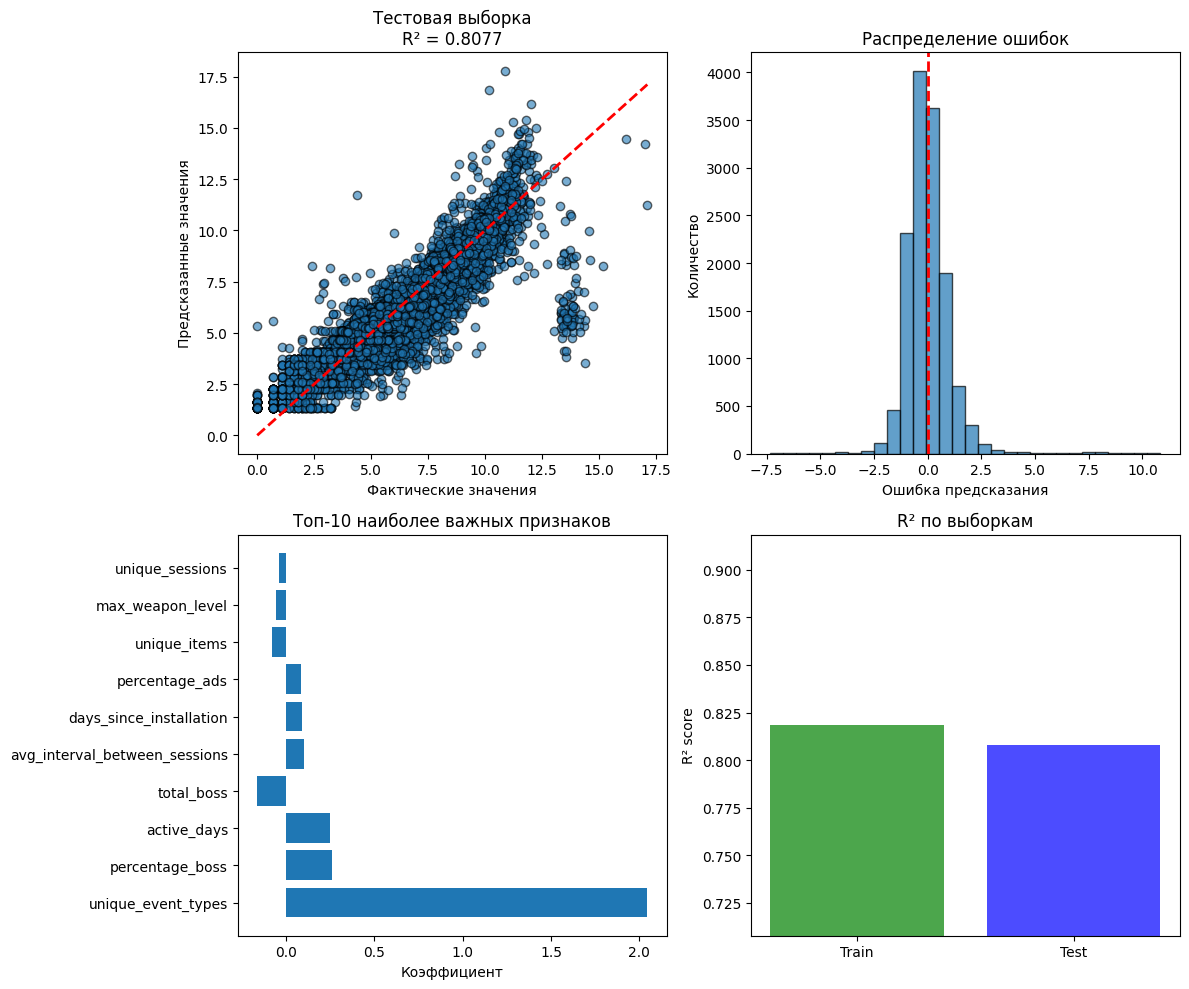

In [15]:
print("\n" + "="*50)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ Linreg:")
print("="*50)

coefficients_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_linreg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coefficients_df.to_string(index=False))
print(f"\nСвободный член (intercept): {model_linreg.intercept_:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test, y_linreg_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения')
axes[0, 0].set_ylabel('Предсказанные значения')
axes[0, 0].set_title(f'Тестовая выборка\nR² = {test_linreg_metrics["r2"]:.4f}')

errors = y_test - y_linreg_test_pred
axes[0, 1].hist(errors, bins=30, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Ошибка предсказания')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_title('Распределение ошибок')

top_features = coefficients_df.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['coefficient'].values)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['feature'].values)
axes[1, 0].set_xlabel('Коэффициент')
axes[1, 0].set_title('Топ-10 наиболее важных признаков')

datasets = ['Train', 'Test']
r2_scores = [train_linreg_metrics['r2'], test_linreg_metrics['r2']]
colors = ['green', 'blue']
axes[1, 1].bar(datasets, r2_scores, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² score')
axes[1, 1].set_title('R² по выборкам')
axes[1, 1].set_ylim([min(r2_scores) - 0.1, max(r2_scores) + 0.1])

plt.tight_layout()
plt.show()


КОЭФФИЦИЕНТЫ МОДЕЛИ Ridge:
                      feature  coefficient
           unique_event_types     2.034331
              percentage_boss     0.261940
                  active_days     0.247343
                   total_boss    -0.163800
avg_interval_between_sessions     0.102670
               percentage_ads     0.088914
      days_since_installation     0.086945
                 unique_items    -0.074156
             max_weapon_level    -0.053731
              unique_sessions    -0.040396
                    total_ads     0.014086
           total_events_count    -0.013243
                  user_rating    -0.009838
                   has_rating     0.007993

Свободный член (intercept): 6.16


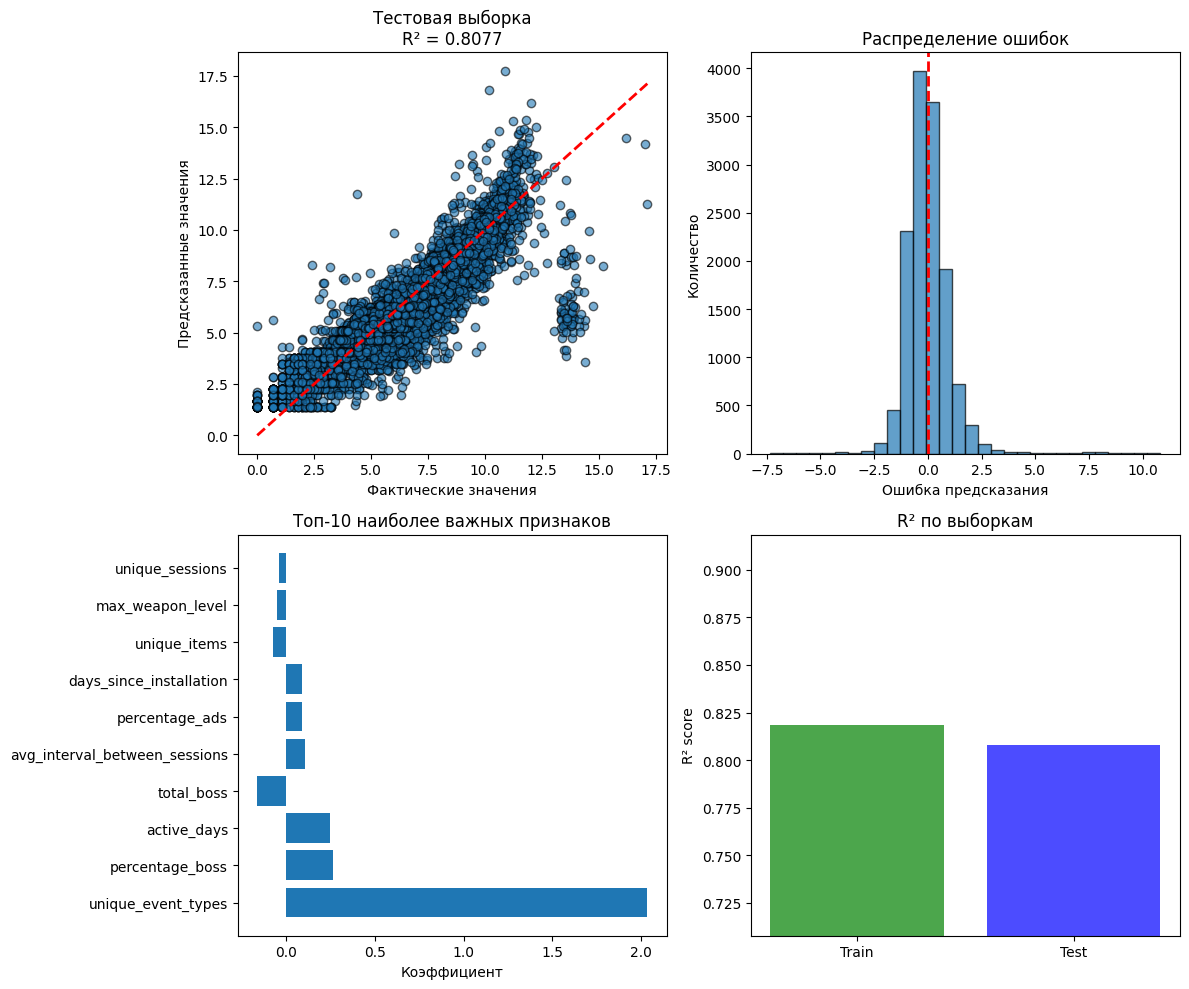

In [16]:
print("\n" + "="*50)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ Ridge:")
print("="*50)

coefficients_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_ridge.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coefficients_df.to_string(index=False))
print(f"\nСвободный член (intercept): {model_ridge.intercept_:.2f}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test, y_ridge_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения')
axes[0, 0].set_ylabel('Предсказанные значения')
axes[0, 0].set_title(f'Тестовая выборка\nR² = {test_ridge_metrics["r2"]:.4f}')

errors = y_test - y_ridge_test_pred
axes[0, 1].hist(errors, bins=30, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Ошибка предсказания')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_title('Распределение ошибок')

top_features = coefficients_df.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['coefficient'].values)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['feature'].values)
axes[1, 0].set_xlabel('Коэффициент')
axes[1, 0].set_title('Топ-10 наиболее важных признаков')

datasets = ['Train', 'Test']
r2_scores = [train_ridge_metrics['r2'], test_ridge_metrics['r2']]
colors = ['green', 'blue']
axes[1, 1].bar(datasets, r2_scores, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² score')
axes[1, 1].set_title('R² по выборкам')
axes[1, 1].set_ylim([min(r2_scores) - 0.1, max(r2_scores) + 0.1])

plt.tight_layout()
plt.show()

In [17]:

joblib.dump(model_linreg, 'linreg_model.joblib')
joblib.dump(model_ridge, 'ridge_model.joblib')

['ridge_model.joblib']

## Детекции выбросов

Перед тем, как мы перейдем к этому блоку, стоит понимать, что в нашем случае Ridge(alpha=1.0) + StandardScaler уже устойчивы к умеренным выбросам. Лишнее удаление точек в признаковом пространстве может навредить качеству нашей модели. 

In [55]:
X_no_outliers = X.copy()
y_no_outliers = y.copy()

In [56]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    """Метод IQR (Interquartile Range)"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    return outliers, lower_bound, upper_bound

In [57]:
def detect_outliers_zscore(data, column, threshold=3):
    """Метод Z-score"""
    z_scores = np.abs(stats.zscore(data[column]))
    outliers = z_scores > threshold
    return outliers

In [58]:
def detect_outliers_isolation_forest(X, contamination=0.05):
    """Isolation Forest"""
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    # -1 для выбросов, 1 для нормальных точек
    outliers = iso_forest.fit_predict(X) == -1
    return outliers

In [59]:
def detect_outliers_lof(X, n_neighbors=20, contamination=0.05):
    """Local Outlier Factor"""
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    outliers = lof.fit_predict(X) == -1
    return outliers

In [60]:
def detect_outliers_residuals(y_true, y_pred, threshold=2.5):
    """Детекция выбросов по остаткам модели"""
    residuals = y_true - y_pred
    std_residual = np.std(residuals)
    mean_residual = np.mean(residuals)
    z_scores = np.abs((residuals - mean_residual) / std_residual)
    return z_scores > threshold

### Метод детекции IQR


Оптимальный k по CV R²: 1.6
Удалено строк: 299
Test R² при этом k: 0.8071


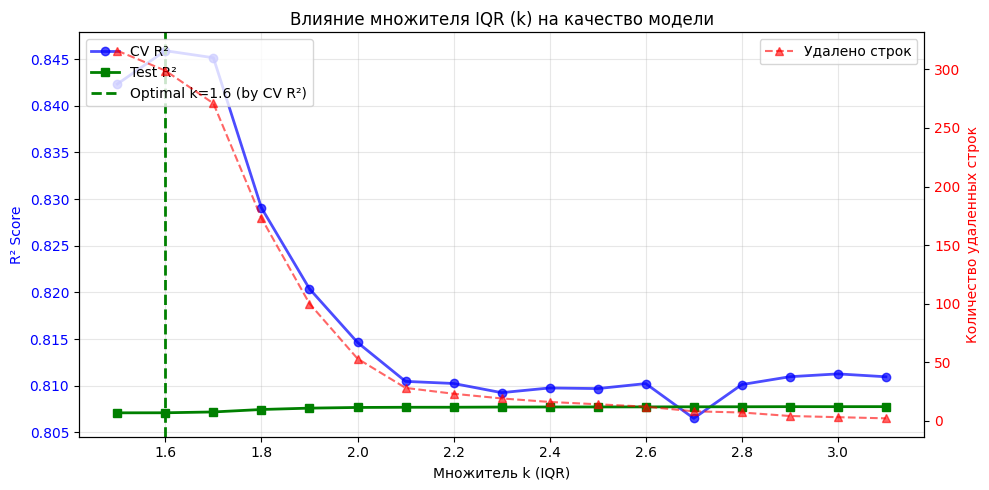


Промежуточные результаты, полученные во время перебора:
  k  удалено_строк  test_r2  cv_r2
1.5            316   0.8071 0.8423
1.6            299   0.8071 0.8459
1.7            271   0.8072 0.8451
1.8            173   0.8074 0.8291
1.9            100   0.8076 0.8204
2.0             53   0.8077 0.8146
2.1             28   0.8077 0.8105
2.2             23   0.8077 0.8102
2.3             19   0.8077 0.8093
2.4             16   0.8077 0.8098
2.5             14   0.8077 0.8097
2.6             12   0.8077 0.8102
2.7              8   0.8077 0.8065
2.8              7   0.8077 0.8101
2.9              4   0.8077 0.8110
3.0              3   0.8077 0.8113
3.1              2   0.8078 0.8110
Лучший CV R² = 0.8459 достигнут при k = 1.6


In [61]:
k_values = np.round(np.arange(1.5, 3.2, 0.1), 1)
results = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    outlier_mask, lb, ub = detect_outliers_iqr(y_train.to_frame('log_total_time_in_game'), 'log_total_time_in_game', multiplier=k)
    X_tr = X_train[~outlier_mask]
    y_tr = y_train[~outlier_mask]
    pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
    cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='r2')
    mean_cv_r2 = cv_scores.mean()
    pipe_test = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
    pipe_test.fit(X_tr, y_tr)
    test_pred = pipe_test.predict(X_test)
    test_r2 = r2_score(y_test, test_pred)
    results.append({'k': k, 'удалено_строк': int(outlier_mask.sum()), 'test_r2': test_r2, 'cv_r2': mean_cv_r2})

df_res = pd.DataFrame(results)

best_idx = df_res['cv_r2'].idxmax()
best_k = df_res.loc[best_idx, 'k']
print()
print(f"Оптимальный k по CV R²: {best_k}")
print(f"Удалено строк: {df_res.loc[best_idx, 'удалено_строк']}")
print(f"Test R² при этом k: {df_res.loc[best_idx, 'test_r2']:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_res['k'], df_res['cv_r2'], 'b-o', label='CV R²', linewidth=2, alpha=0.7)
ax1.plot(df_res['k'], df_res['test_r2'], 'g-s', label='Test R²', linewidth=2)
ax1.set_xlabel('Множитель k (IQR)')
ax1.set_ylabel('R² Score', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_res['k'], df_res['удалено_строк'], 'r--^', label='Удалено строк', alpha=0.6)
ax2.set_ylabel('Количество удаленных строк', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Влияние множителя IQR (k) на качество модели')
ax1.axvline(best_k, color='green', linestyle='--', linewidth=2, label=f'Optimal k={best_k} (by CV R²)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

print()
print("Промежуточные результаты, полученные во время перебора:")
df_display = df_res.round(4).copy()
df_display['best'] = df_display['cv_r2'] == df_res['cv_r2'].max()
print(df_display[['k', 'удалено_строк', 'test_r2', 'cv_r2']].to_string(index=False))
print(f"Лучший CV R² = {df_res['cv_r2'].max():.4f} достигнут при k = {best_k}")

На представленном выше графике можно увидеть зависимость качества модели регрессии от множителя $k$ в методе Interquartile Range (IQR), используемом для детекции выбросов в целевой переменной. Синяя сплошная линия с кругами отображает коэффициент детерминации $R^2$ на кросс-валидации (левая ось ординат). Значение метрики снижается с увеличением $k$, достигая максимума $0.8459$ при $k = 1.6$, что указывает на оптимальный баланс между очисткой данных и сохранением информации для обучения. Красная пунктирная линия с треугольниками показывает количество наблюдений, которые были удалены из обучающей выборки (правая ось ординат). При малых значениях $k$ ($1.5$ – $1.8$) удаляется $150–300$ строк, тогда как при $k$ больше или равным $2.5$ количество удалённых наблюдений не превышает $20$. Зелёная вертикальная пунктирная линия отмечает оптимальное значение множителя $k = 1.6$, при котором достигнуто максимальное значение коэффициента детерминации $R^2$ на кросс-валидации. При этом значении параметра модель демонстрирует на тестовой выборке $R^2 = 0.8071$.

In [62]:
outlier_mask, lower_bound, upper_bound = detect_outliers_iqr(y_train.to_frame('log_total_time_in_game'), 'log_total_time_in_game', best_k)

In [63]:
X_train_clean = X_train[~outlier_mask]
y_train_clean = y_train[~outlier_mask]

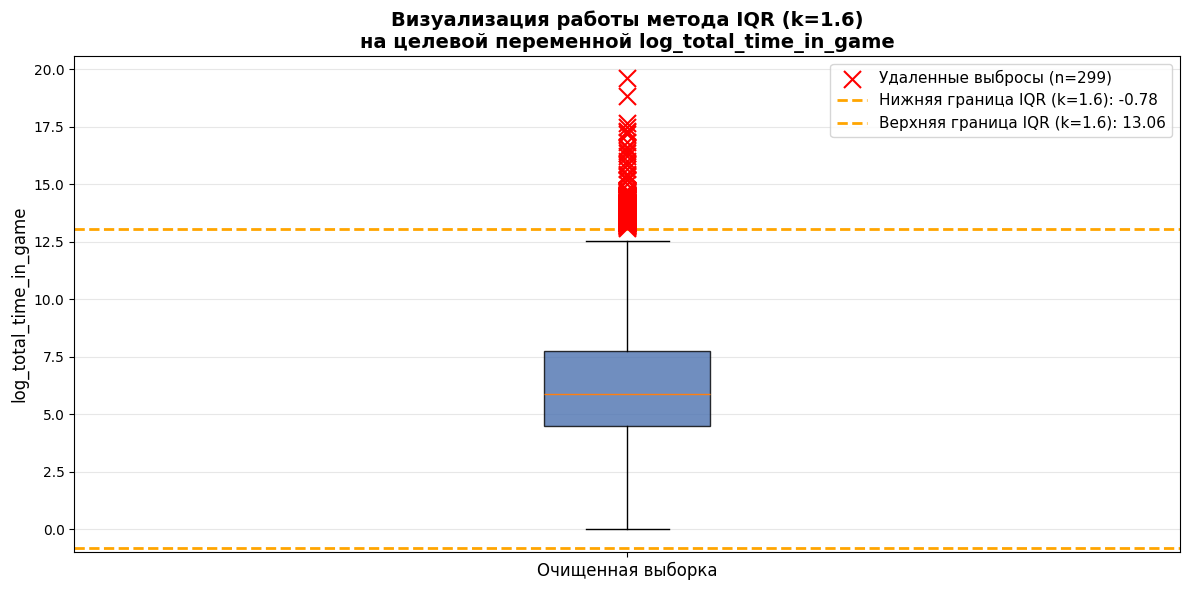

Всего наблюдений: 54835
Удалено выбросов: 299 (0.5452721801768944%)
Осталось в выборке: 54536
Диапазон допустимых значений: [-0.7837035177853826; 13.056188686948113]
Размер test (без изменений): 13709


In [64]:
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(y_train_clean, vert=True, patch_artist=True, showfliers=False)

for patch in bp['boxes']:
    patch.set_facecolor('#4C72B0')
    patch.set_alpha(0.8)
outliers_indices = np.where(outlier_mask)[0]
outliers_values = y_train[outlier_mask].values
ax.scatter([1.0] * len(outliers_values), outliers_values, color='red', marker='x', s=150, zorder=5, label=f'Удаленные выбросы (n={len(outliers_values)})')
ax.axhline(y=lower_bound, color='orange', linestyle='--', linewidth=2, label=f'Нижняя граница IQR (k={best_k}): {lower_bound:.2f}')
ax.axhline(y=upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Верхняя граница IQR (k={best_k}): {upper_bound:.2f}')
ax.set_title(f'Визуализация работы метода IQR (k={best_k})\nна целевой переменной log_total_time_in_game', fontsize=14, fontweight='bold')
ax.set_ylabel('log_total_time_in_game', fontsize=12)
ax.set_xticklabels(['Очищенная выборка'], fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Всего наблюдений: {len(y_train)}")
print(f"Удалено выбросов: {len(outliers_values)} ({len(outliers_values)/len(y_train)*100}%)")
print(f"Осталось в выборке: {len(y_train_clean)}")
print(f"Диапазон допустимых значений: [{lower_bound}; {upper_bound}]")
print(f"Размер test (без изменений): {len(X_test)}")

На приведенном выше графике можно заметить, что метод IQR с коэффициентом $k = 1.6$ работает как фильтр экстремальных значений. Из более чем $54 000$ наблюдений было удалено $299$ выбросов, находившихся за верхней границей допустимого диапазона ($13.06$). Это демонстрирует, что основная масса данных (голубой блок) является однородной, а выбранный порог очистки позволяет устранить наиболее выраженные выбросы в целевой переменной. При этом параметр $k$ был подобран именно по метрике кросс-валидации, что обеспечивает оптимальный баланс между исключением аномальных данных и сохранением структуры данных для обучения модели, даже если это приводит к незначительному снижению метрик на тестовой выборке по сравнению с базовым вариантом.

In [65]:
scaler_clean = StandardScaler()
X_train_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_scaled = scaler_clean.transform(X_test)

In [66]:
X_ready = X_train_scaled
y_ready = y_train_clean

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    model = Ridge(alpha=alpha)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(model, X_ready, y_ready, cv=cv, scoring='r2', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_alpha = study.best_params['alpha']
print(f"Лучший alpha: {best_alpha:.4f}")
print(f"CV R²: {study.best_value:.4f}")

[I 2026-06-12 17:57:43,507] A new study created in memory with name: no-name-0adf037b-ab20-4941-90c7-5358753cc321
Best trial: 0. Best value: 0.845902:   2%|▏         | 1/50 [00:06<05:25,  6.63s/it]

[I 2026-06-12 17:57:50,145] Trial 0 finished with value: 0.8459022207599898 and parameters: {'alpha': 0.03148911647956861}. Best is trial 0 with value: 0.8459022207599898.


Best trial: 1. Best value: 0.845933:   4%|▍         | 2/50 [00:10<04:01,  5.04s/it]

[I 2026-06-12 17:57:54,067] Trial 1 finished with value: 0.8459331196655592 and parameters: {'alpha': 6.351221010640703}. Best is trial 1 with value: 0.8459331196655592.


Best trial: 1. Best value: 0.845933:   6%|▌         | 3/50 [00:15<03:52,  4.94s/it]

[I 2026-06-12 17:57:58,882] Trial 2 finished with value: 0.8459062231625802 and parameters: {'alpha': 0.8471801418819978}. Best is trial 1 with value: 0.8459331196655592.


Best trial: 1. Best value: 0.845933:   8%|▊         | 4/50 [00:21<04:01,  5.26s/it]

[I 2026-06-12 17:58:04,623] Trial 3 finished with value: 0.8459032840514539 and parameters: {'alpha': 0.24810409748678125}. Best is trial 1 with value: 0.8459331196655592.


Best trial: 1. Best value: 0.845933:  12%|█▏        | 6/50 [00:21<01:42,  2.33s/it]

[I 2026-06-12 17:58:04,861] Trial 4 finished with value: 0.84590208682475 and parameters: {'alpha': 0.004207988669606638}. Best is trial 1 with value: 0.8459331196655592.
[I 2026-06-12 17:58:05,032] Trial 5 finished with value: 0.8459020868201609 and parameters: {'alpha': 0.004207053950287938}. Best is trial 1 with value: 0.8459331196655592.


Best trial: 1. Best value: 0.845933:  14%|█▍        | 7/50 [00:21<01:09,  1.63s/it]

[I 2026-06-12 17:58:05,208] Trial 6 finished with value: 0.8459020745479904 and parameters: {'alpha': 0.0017073967431528124}. Best is trial 1 with value: 0.8459331196655592.
[I 2026-06-12 17:58:05,386] Trial 7 finished with value: 0.8459163526675418 and parameters: {'alpha': 2.9154431891537547}. Best is trial 1 with value: 0.8459331196655592.


Best trial: 1. Best value: 0.845933:  20%|██        | 10/50 [00:22<00:25,  1.55it/s]

[I 2026-06-12 17:58:05,581] Trial 8 finished with value: 0.8459033119161807 and parameters: {'alpha': 0.2537815508265665}. Best is trial 1 with value: 0.8459331196655592.
[I 2026-06-12 17:58:05,747] Trial 9 finished with value: 0.8459054015157796 and parameters: {'alpha': 0.679657809075816}. Best is trial 1 with value: 0.8459331196655592.


[I 2026-06-12 17:58:06,001] Trial 10 finished with value: 0.8459424948395693 and parameters: {'alpha': 8.279028516239514}. Best is trial 10 with value: 0.8459424948395693.


Best trial: 10. Best value: 0.845942:  26%|██▌       | 13/50 [00:22<00:12,  2.90it/s]

[I 2026-06-12 17:58:06,185] Trial 11 finished with value: 0.8459284278193738 and parameters: {'alpha': 5.388253252984512}. Best is trial 10 with value: 0.8459424948395693.
[I 2026-06-12 17:58:06,355] Trial 12 finished with value: 0.8459389692786707 and parameters: {'alpha': 7.553503645583182}. Best is trial 10 with value: 0.8459424948395693.


Best trial: 14. Best value: 0.845947:  30%|███       | 15/50 [00:23<00:08,  3.91it/s]

[I 2026-06-12 17:58:06,523] Trial 13 finished with value: 0.8459101653951265 and parameters: {'alpha': 1.6514533655515913}. Best is trial 10 with value: 0.8459424948395693.
[I 2026-06-12 17:58:06,694] Trial 14 finished with value: 0.8459469758279807 and parameters: {'alpha': 9.202160576733972}. Best is trial 14 with value: 0.8459469758279807.


Best trial: 14. Best value: 0.845947:  34%|███▍      | 17/50 [00:23<00:06,  4.72it/s]

[I 2026-06-12 17:58:06,862] Trial 15 finished with value: 0.8459021827137703 and parameters: {'alpha': 0.023739423955292552}. Best is trial 14 with value: 0.8459469758279807.
[I 2026-06-12 17:58:07,035] Trial 16 finished with value: 0.8459110235183595 and parameters: {'alpha': 1.8266344041193754}. Best is trial 14 with value: 0.8459469758279807.


Best trial: 14. Best value: 0.845947:  38%|███▊      | 19/50 [00:23<00:05,  5.30it/s]

[I 2026-06-12 17:58:07,201] Trial 17 finished with value: 0.845902777615281 and parameters: {'alpha': 0.14492473635015288}. Best is trial 14 with value: 0.8459469758279807.
[I 2026-06-12 17:58:07,368] Trial 18 finished with value: 0.8459062532963456 and parameters: {'alpha': 0.853324688983006}. Best is trial 14 with value: 0.8459469758279807.


Best trial: 19. Best value: 0.84595:  42%|████▏     | 21/50 [00:24<00:05,  5.58it/s] 

[I 2026-06-12 17:58:07,539] Trial 19 finished with value: 0.845949841992377 and parameters: {'alpha': 9.793203726045522}. Best is trial 19 with value: 0.845949841992377.
[I 2026-06-12 17:58:07,708] Trial 20 finished with value: 0.845902357864009 and parameters: {'alpha': 0.05941668965297967}. Best is trial 19 with value: 0.845949841992377.


Best trial: 19. Best value: 0.84595:  46%|████▌     | 23/50 [00:24<00:04,  5.68it/s]

[I 2026-06-12 17:58:07,878] Trial 21 finished with value: 0.8459411185083535 and parameters: {'alpha': 7.995711921718729}. Best is trial 19 with value: 0.845949841992377.
[I 2026-06-12 17:58:08,055] Trial 22 finished with value: 0.8459162422390344 and parameters: {'alpha': 2.8928657015313313}. Best is trial 19 with value: 0.845949841992377.


Best trial: 19. Best value: 0.84595:  50%|█████     | 25/50 [00:24<00:04,  5.73it/s]

[I 2026-06-12 17:58:08,223] Trial 23 finished with value: 0.8459473786540528 and parameters: {'alpha': 9.285201475298665}. Best is trial 19 with value: 0.845949841992377.
[I 2026-06-12 17:58:08,394] Trial 24 finished with value: 0.8459193726474146 and parameters: {'alpha': 3.5331452097559457}. Best is trial 19 with value: 0.845949841992377.


Best trial: 19. Best value: 0.84595:  54%|█████▍    | 27/50 [00:25<00:04,  5.65it/s]

[I 2026-06-12 17:58:08,586] Trial 25 finished with value: 0.845908904478439 and parameters: {'alpha': 1.3941165518456238}. Best is trial 19 with value: 0.845949841992377.
[I 2026-06-12 17:58:08,761] Trial 26 finished with value: 0.845903937052119 and parameters: {'alpha': 0.38116433359926216}. Best is trial 19 with value: 0.845949841992377.


Best trial: 27. Best value: 0.84595:  56%|█████▌    | 28/50 [00:25<00:03,  5.64it/s]

[I 2026-06-12 17:58:08,936] Trial 27 finished with value: 0.8459504926621622 and parameters: {'alpha': 9.92744430814271}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  58%|█████▊    | 29/50 [00:25<00:04,  5.20it/s]

[I 2026-06-12 17:58:09,166] Trial 28 finished with value: 0.8459201907216627 and parameters: {'alpha': 3.7005581994758074}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  62%|██████▏   | 31/50 [00:26<00:03,  5.48it/s]

[I 2026-06-12 17:58:09,344] Trial 29 finished with value: 0.8459022405103968 and parameters: {'alpha': 0.035512137719444455}. Best is trial 27 with value: 0.8459504926621622.
[I 2026-06-12 17:58:09,512] Trial 30 finished with value: 0.8459111502473083 and parameters: {'alpha': 1.8525087835738567}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  66%|██████▌   | 33/50 [00:26<00:03,  5.56it/s]

[I 2026-06-12 17:58:09,694] Trial 31 finished with value: 0.8459502962722603 and parameters: {'alpha': 9.886924363460965}. Best is trial 27 with value: 0.8459504926621622.
[I 2026-06-12 17:58:09,869] Trial 32 finished with value: 0.8459245278275649 and parameters: {'alpha': 4.588724379493519}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  68%|██████▊   | 34/50 [00:26<00:02,  5.56it/s]

[I 2026-06-12 17:58:10,044] Trial 33 finished with value: 0.8459235759734106 and parameters: {'alpha': 4.393712884432456}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  70%|███████   | 35/50 [00:26<00:02,  5.29it/s]

[I 2026-06-12 17:58:10,249] Trial 34 finished with value: 0.8459484196156852 and parameters: {'alpha': 9.499832920910258}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  74%|███████▍  | 37/50 [00:27<00:02,  5.40it/s]

[I 2026-06-12 17:58:10,467] Trial 35 finished with value: 0.8459071203371924 and parameters: {'alpha': 1.0301431431083539}. Best is trial 27 with value: 0.8459504926621622.
[I 2026-06-12 17:58:10,633] Trial 36 finished with value: 0.8459137036122678 and parameters: {'alpha': 2.374017178580072}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  76%|███████▌  | 38/50 [00:27<00:02,  5.42it/s]

[I 2026-06-12 17:58:10,801] Trial 37 finished with value: 0.8459045003835207 and parameters: {'alpha': 0.4959713565737128}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 27. Best value: 0.84595:  80%|████████  | 40/50 [00:27<00:01,  5.42it/s]

[I 2026-06-12 17:58:11,013] Trial 38 finished with value: 0.8459021175503569 and parameters: {'alpha': 0.010466369837118256}. Best is trial 27 with value: 0.8459504926621622.
[I 2026-06-12 17:58:11,186] Trial 39 finished with value: 0.8459292672210544 and parameters: {'alpha': 5.560445893817445}. Best is trial 27 with value: 0.8459504926621622.


Best trial: 40. Best value: 0.845951:  84%|████████▍ | 42/50 [00:28<00:01,  5.60it/s]

[I 2026-06-12 17:58:11,370] Trial 40 finished with value: 0.8459505605442283 and parameters: {'alpha': 9.941450502972573}. Best is trial 40 with value: 0.8459505605442283.
[I 2026-06-12 17:58:11,537] Trial 41 finished with value: 0.8459288154411558 and parameters: {'alpha': 5.467764170217338}. Best is trial 40 with value: 0.8459505605442283.


Best trial: 40. Best value: 0.845951:  88%|████████▊ | 44/50 [00:28<00:01,  5.79it/s]

[I 2026-06-12 17:58:11,702] Trial 42 finished with value: 0.8459164706680955 and parameters: {'alpha': 2.93956953927343}. Best is trial 40 with value: 0.8459505605442283.
[I 2026-06-12 17:58:11,873] Trial 43 finished with value: 0.8459503722477107 and parameters: {'alpha': 9.902599666633746}. Best is trial 40 with value: 0.8459505605442283.


Best trial: 45. Best value: 0.845951:  92%|█████████▏| 46/50 [00:28<00:00,  5.81it/s]

[I 2026-06-12 17:58:12,044] Trial 44 finished with value: 0.8459265523802723 and parameters: {'alpha': 5.003669837757073}. Best is trial 40 with value: 0.8459505605442283.
[I 2026-06-12 17:58:12,215] Trial 45 finished with value: 0.8459505800925429 and parameters: {'alpha': 9.945483979496762}. Best is trial 45 with value: 0.8459505800925429.


Best trial: 45. Best value: 0.845951:  96%|█████████▌| 48/50 [00:29<00:00,  5.76it/s]

[I 2026-06-12 17:58:12,395] Trial 46 finished with value: 0.845933476876662 and parameters: {'alpha': 6.424585444995903}. Best is trial 45 with value: 0.8459505800925429.
[I 2026-06-12 17:58:12,567] Trial 47 finished with value: 0.8459077906972254 and parameters: {'alpha': 1.1668796565450918}. Best is trial 45 with value: 0.8459505800925429.


Best trial: 45. Best value: 0.845951: 100%|██████████| 50/50 [00:29<00:00,  1.70it/s]

[I 2026-06-12 17:58:12,734] Trial 48 finished with value: 0.8459128802428818 and parameters: {'alpha': 2.205810694217755}. Best is trial 45 with value: 0.8459505800925429.
[I 2026-06-12 17:58:12,907] Trial 49 finished with value: 0.8459326462155226 and parameters: {'alpha': 6.253994073305037}. Best is trial 45 with value: 0.8459505800925429.
Лучший alpha: 9.9455
CV R²: 0.8460


In [67]:
model_linreg_clean = LinearRegression()
model_ridge_clean = Ridge(alpha=best_alpha)

model_linreg_clean.fit(X_train_scaled, y_train_clean)
model_ridge_clean.fit(X_train_scaled, y_train_clean)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",9.945483979496762
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gra

In [68]:
models = {
    "linreg": model_linreg,
    "ridge": model_ridge,
    "linreg_no_outlayers": model_linreg_clean, 
    "ridge_no_outlayers": model_ridge_clean
    }

print("Полученные коэффициенты моделей:")

for name, model in models.items():
    print(f"model {name}: {model.coef_}\n")

Полученные коэффициенты моделей:
model linreg: [ 0.08761613  0.10269882 -0.00985939 -0.05566229 -0.08111747 -0.04105809
  0.24804192  2.04592413 -0.01353325  0.01491631 -0.1645254   0.08626586
  0.26201834  0.00655856]

model ridge: [ 0.08694502  0.10267007 -0.0098384  -0.0537313  -0.07415584 -0.040396
  0.24734254  2.03433064 -0.01324254  0.01408595 -0.16380047  0.08891381
  0.26193989  0.00799295]

model linreg_no_outlayers: [ 0.08496343  0.09913148 -0.00947313 -0.03351535 -0.06448395  0.00308085
  0.21177005  2.01431956 -0.01568316 -0.0338316  -0.16925117  0.11016471
  0.26983939  0.00475076]

model ridge_no_outlayers: [ 0.0848964   0.09912685 -0.00947101 -0.03333503 -0.06379531  0.00311539
  0.21172662  2.01317415 -0.01565417 -0.03389108 -0.16917954  0.1104224
  0.26982907  0.00489324]



In [69]:
y_linreg_clean_train_pred = model_linreg_clean.predict(X_train_scaled)
y_linreg_clean_test_pred = model_linreg_clean.predict(X_test_scaled)

y_ridge_clean_train_pred = model_ridge_clean.predict(X_train_scaled)
y_ridge_clean_test_pred = model_ridge_clean.predict(X_test_scaled)

In [70]:
train_linreg_clean_metrics = evaluate_model(y_train_clean, y_linreg_clean_train_pred, "Обучающая выборка", "linreg", "IQR")
test_linreg_clean_metrics = evaluate_model(y_test, y_linreg_clean_test_pred, "Тестовая выборка", "linreg", "IQR")

train_ridge_clean_metrics = evaluate_model(y_train_clean, y_ridge_clean_train_pred, "Обучающая выборка", "ridge_clean", "IQR")
test_ridge_clean_metrics = evaluate_model(y_test, y_ridge_clean_test_pred, "Тестовая выборка", "ridge_clean", "IQR")


МЕТРИКИ КАЧЕСТВА linreg, детецкия выбросов: IQR

Обучающая выборка:
  R² (коэффициент детерминации): 0.8553596195944644
  MSE (среднеквадратичная ошибка): 0.7710403152801143
  RMSE (корень из MSE): 0.8780890133011084
  MAE (средняя абсолютная ошибка): 0.6588236342071854


МЕТРИКИ КАЧЕСТВА linreg, детецкия выбросов: IQR

Тестовая выборка:
  R² (коэффициент детерминации): 0.807094718455405
  MSE (среднеквадратичная ошибка): 1.071081738548333
  RMSE (корень из MSE): 1.034930789255172
  MAE (средняя абсолютная ошибка): 0.6963005459922611


МЕТРИКИ КАЧЕСТВА ridge_clean, детецкия выбросов: IQR

Обучающая выборка:
  R² (коэффициент детерминации): 0.8553595390193116
  MSE (среднеквадратичная ошибка): 0.7710407448053348
  RMSE (корень из MSE): 0.8780892578806182
  MAE (средняя абсолютная ошибка): 0.6588542407443799


МЕТРИКИ КАЧЕСТВА ridge_clean, детецкия выбросов: IQR

Тестовая выборка:
  R² (коэффициент детерминации): 0.8070927266923478
  MSE (среднеквадратичная ошибка): 1.071092797556262
  

Мы нашли оптимальный гипер-параметр, равный $k = 3.1$, который дал нам прирост качества модели на тестовой выборке. В данном случае, можно заметить, что у нас улучшились значения таких метрик, как $R^2$, $MSE$, $RMSE$ и $MAE$.

In [71]:
results = []

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'Нет',
    'Train R²': train_linreg_metrics['r2'],
    'Test R²': test_linreg_metrics['r2'],
    'Test RMSE': test_linreg_metrics['rmse'],
    'Test MAE': test_linreg_metrics['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'Нет',
    'Train R²': train_ridge_metrics['r2'],
    'Test R²': test_ridge_metrics['r2'],
    'Test RMSE': test_ridge_metrics['rmse'],
    'Test MAE': test_ridge_metrics['mae']
})

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'IQR',
    'Train R²': train_linreg_clean_metrics['r2'],
    'Test R²': test_linreg_clean_metrics['r2'],
    'Test RMSE': test_linreg_clean_metrics['rmse'],
    'Test MAE': test_linreg_clean_metrics['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'IQR',
    'Train R²': train_ridge_clean_metrics['r2'],
    'Test R²': test_ridge_clean_metrics['r2'],
    'Test RMSE': test_ridge_clean_metrics['rmse'],
    'Test MAE': test_ridge_clean_metrics['mae']
})

df_results = pd.DataFrame(results)
print(df_results[['Модель', 'Детекция', 'Train R²', 'Test R²', 'Test RMSE', 'Test MAE']].to_string(index=False))
best_idx = df_results['Test R²'].idxmax()
print(f"\n✓ Лучшая модель по Test R²: {df_results.loc[best_idx, 'Модель']} + {df_results.loc[best_idx, 'Детекция']} (R² = {df_results.loc[best_idx, 'Test R²']:.4f})")

           Модель Детекция  Train R²  Test R²  Test RMSE  Test MAE
Linear Regression      Нет  0.818559 0.807690   1.033333  0.698088
 Ridge Regression      Нет  0.818551 0.807699   1.033309  0.698268
Linear Regression      IQR  0.855360 0.807095   1.034931  0.696301
 Ridge Regression      IQR  0.855360 0.807093   1.034936  0.696328

✓ Лучшая модель по Test R²: Ridge Regression + Нет (R² = 0.8077)



КОЭФФИЦИЕНТЫ МОДЕЛИ Linreg (Clean Model):
                      feature  coefficient
           unique_event_types     2.014320
              percentage_boss     0.269839
                  active_days     0.211770
                   total_boss    -0.169251
               percentage_ads     0.110165
avg_interval_between_sessions     0.099131
      days_since_installation     0.084963
                 unique_items    -0.064484
                    total_ads    -0.033832
             max_weapon_level    -0.033515
           total_events_count    -0.015683
                  user_rating    -0.009473
                   has_rating     0.004751
              unique_sessions     0.003081

Свободный член (intercept): 6.11


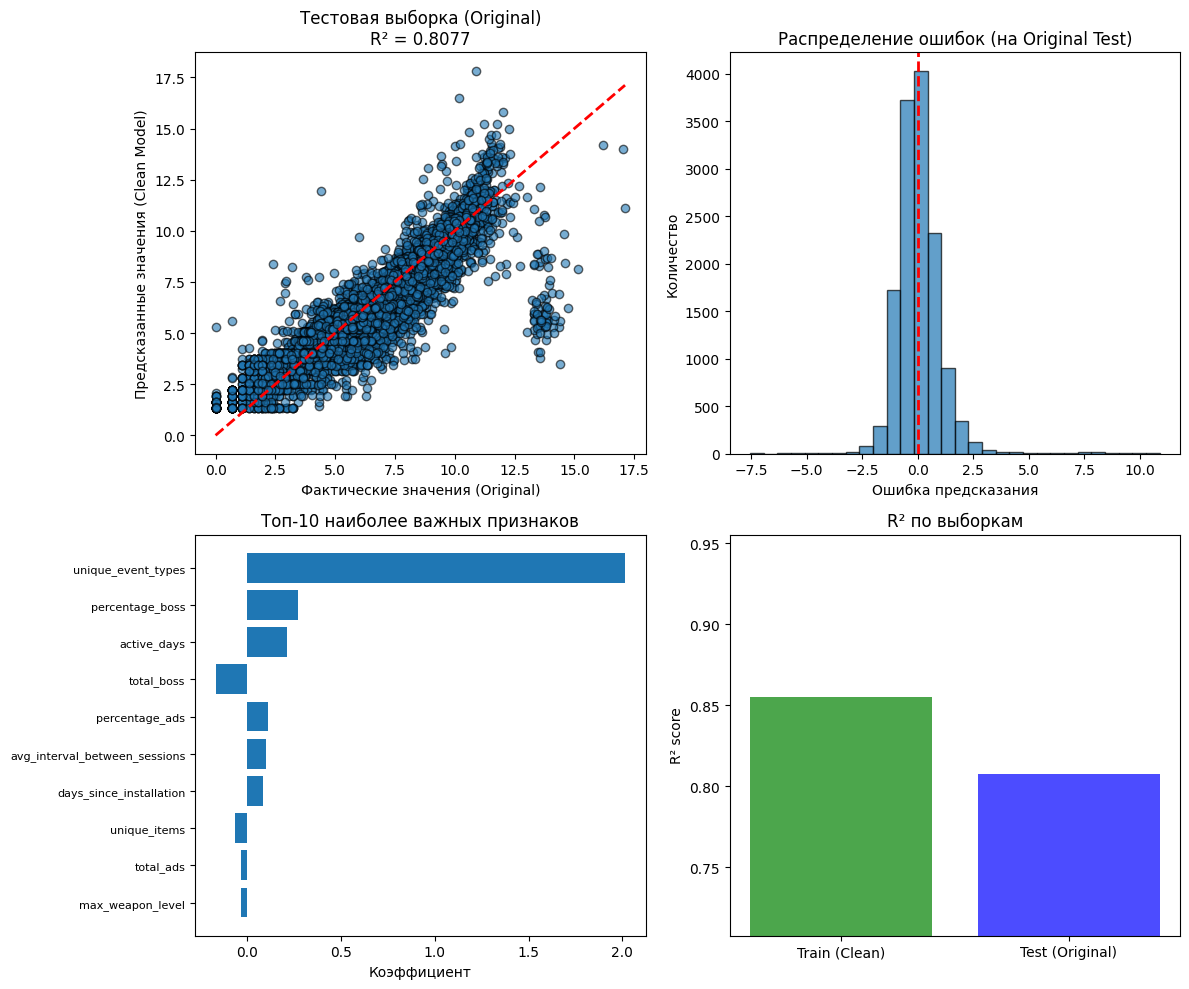

In [72]:
print("\n" + "="*50)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ Linreg (Clean Model):")
print("="*50)

coefficients_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_linreg_clean.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(coefficients_df.to_string(index=False))
print(f"\nСвободный член (intercept): {model_linreg_clean.intercept_:.2f}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test, y_linreg_clean_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения (Original)')
axes[0, 0].set_ylabel('Предсказанные значения (Clean Model)')
axes[0, 0].set_title(f'Тестовая выборка (Original)\nR² = {test_linreg_metrics["r2"]:.4f}')


errors = y_test - y_linreg_clean_test_pred
axes[0, 1].hist(errors, bins=30, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Ошибка предсказания')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_title('Распределение ошибок (на Original Test)')


top_features = coefficients_df.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['coefficient'].values)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['feature'].values, rotation=0, fontsize=8)
axes[1, 0].set_xlabel('Коэффициент')
axes[1, 0].set_title('Топ-10 наиболее важных признаков')
axes[1, 0].invert_yaxis()


datasets = ['Train (Clean)', 'Test (Original)']
r2_scores = [train_linreg_clean_metrics['r2'], test_linreg_metrics['r2']]
colors = ['green', 'blue']
axes[1, 1].bar(datasets, r2_scores, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² score')
axes[1, 1].set_title('R² по выборкам')
axes[1, 1].set_ylim([min(r2_scores) - 0.1, max(r2_scores) + 0.1])

plt.tight_layout()
plt.show()


КОЭФФИЦИЕНТЫ МОДЕЛИ Ridge (Clean Model):
                      feature  coefficient
           unique_event_types     2.013174
              percentage_boss     0.269829
                  active_days     0.211727
                   total_boss    -0.169180
               percentage_ads     0.110422
avg_interval_between_sessions     0.099127
      days_since_installation     0.084896
                 unique_items    -0.063795
                    total_ads    -0.033891
             max_weapon_level    -0.033335
           total_events_count    -0.015654
                  user_rating    -0.009471
                   has_rating     0.004893
              unique_sessions     0.003115

Свободный член (intercept): 6.11


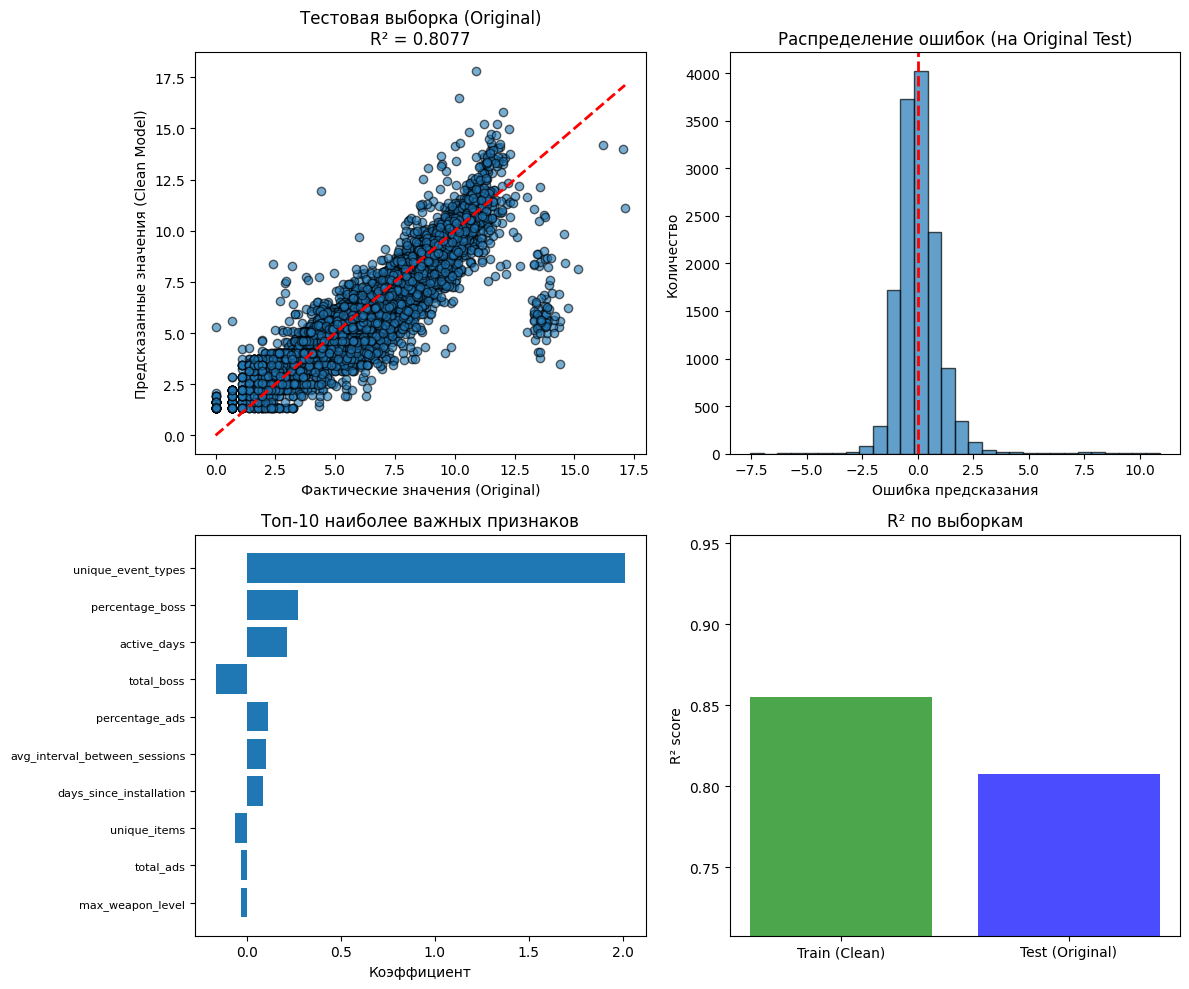

In [73]:
print("\n" + "="*50)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ Ridge (Clean Model):")
print("="*50)

coefficients_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_ridge_clean.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(coefficients_df.to_string(index=False))
print(f"\nСвободный член (intercept): {model_ridge_clean.intercept_:.2f}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))


axes[0, 0].scatter(y_test, y_ridge_clean_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения (Original)')
axes[0, 0].set_ylabel('Предсказанные значения (Clean Model)')
axes[0, 0].set_title(f'Тестовая выборка (Original)\nR² = {test_ridge_metrics["r2"]:.4f}')


errors = y_test - y_ridge_clean_test_pred
axes[0, 1].hist(errors, bins=30, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Ошибка предсказания')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_title('Распределение ошибок (на Original Test)')


top_features = coefficients_df.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['coefficient'].values)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['feature'].values, rotation=0, fontsize=8)
axes[1, 0].set_xlabel('Коэффициент')
axes[1, 0].set_title('Топ-10 наиболее важных признаков')
axes[1, 0].invert_yaxis()


datasets = ['Train (Clean)', 'Test (Original)']
r2_scores = [train_ridge_clean_metrics['r2'], test_ridge_metrics['r2']]
colors = ['green', 'blue']
axes[1, 1].bar(datasets, r2_scores, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² score')
axes[1, 1].set_title('R² по выборкам')
axes[1, 1].set_ylim([min(r2_scores) - 0.1, max(r2_scores) + 0.1])

plt.tight_layout()
plt.show()

### Метод детекции Isolation Forest

In [74]:
contamination_grid = np.linspace(0.00001, 0.1, 50)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
cv = KFold(n_splits=5, shuffle=True, random_state=42)

best_cont = None
best_cv_r2 = -np.inf
results = []

for cont in contamination_grid:
    iso = IsolationForest(contamination=cont, random_state=42)
    mask = iso.fit_predict(X_train) != -1
    X_tr, y_tr = X_train[mask], y_train[mask]
    if len(X_tr) < 200:
        print(f"️ contamination={cont:.4f}: Пропущено (осталось < 200 строк)")
        continue
    cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='r2')
    mean_cv_r2 = cv_scores.mean()
    pipe.fit(X_tr, y_tr)
    y_pred_test = pipe.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    results.append({
        'contamination': cont,
        'осталось_строк': len(X_tr),
        'test_r2': test_r2,
        'cv_r2': mean_cv_r2
    })
    print(f"contamination={cont:.4f}: Test R² = {test_r2:.4f} | CV R² = {mean_cv_r2:.4f} | Осталось строк: {len(X_tr)}")
    if mean_cv_r2 > best_cv_r2:
        best_cv_r2 = mean_cv_r2
        best_cont = cont

print("="*65)
print(f"Оптимальный contamination: {best_cont:.4f} (CV R² = {best_cv_r2:.4f})")

df_results = pd.DataFrame(results)
print()
print("Пять наилучших значений параметра по значению CV R²:")
print(df_results.nlargest(5, 'cv_r2')[['contamination', 'осталось_строк', 'test_r2', 'cv_r2']].round(4).to_string(index=False))

contamination=0.0000: Test R² = 0.8077 | CV R² = 0.8102 | Осталось строк: 54834
contamination=0.0021: Test R² = 0.8076 | CV R² = 0.8113 | Осталось строк: 54722
contamination=0.0041: Test R² = 0.8074 | CV R² = 0.8121 | Осталось строк: 54610
contamination=0.0061: Test R² = 0.8072 | CV R² = 0.8096 | Осталось строк: 54498
contamination=0.0082: Test R² = 0.8068 | CV R² = 0.8101 | Осталось строк: 54386
contamination=0.0102: Test R² = 0.8065 | CV R² = 0.8078 | Осталось строк: 54274
contamination=0.0123: Test R² = 0.8060 | CV R² = 0.8089 | Осталось строк: 54163
contamination=0.0143: Test R² = 0.8058 | CV R² = 0.8076 | Осталось строк: 54051
contamination=0.0163: Test R² = 0.8051 | CV R² = 0.8077 | Осталось строк: 53939
contamination=0.0184: Test R² = 0.8045 | CV R² = 0.8069 | Осталось строк: 53827
contamination=0.0204: Test R² = 0.8042 | CV R² = 0.8059 | Осталось строк: 53715
contamination=0.0225: Test R² = 0.8037 | CV R² = 0.8055 | Осталось строк: 53603
contamination=0.0245: Test R² = 0.8032 |

In [75]:
iso_forest = IsolationForest(contamination=best_cont, random_state=42)

outlier_mask_train = iso_forest.fit_predict(X_train) == -1

print(f"МЕТОД: Isolation Forest (на исходных данных)")
print(f"Найдено новых выбросов: {outlier_mask_train.sum()} из {len(y_train)}")
print(f"Процент выбросов: {outlier_mask_train.sum() / len(y_train) * 100:.2f}%")

МЕТОД: Isolation Forest (на исходных данных)
Найдено новых выбросов: 225 из 54835
Процент выбросов: 0.41%


In [76]:
X_train_iso = X_train[~outlier_mask_train]
y_train_iso = y_train[~outlier_mask_train]

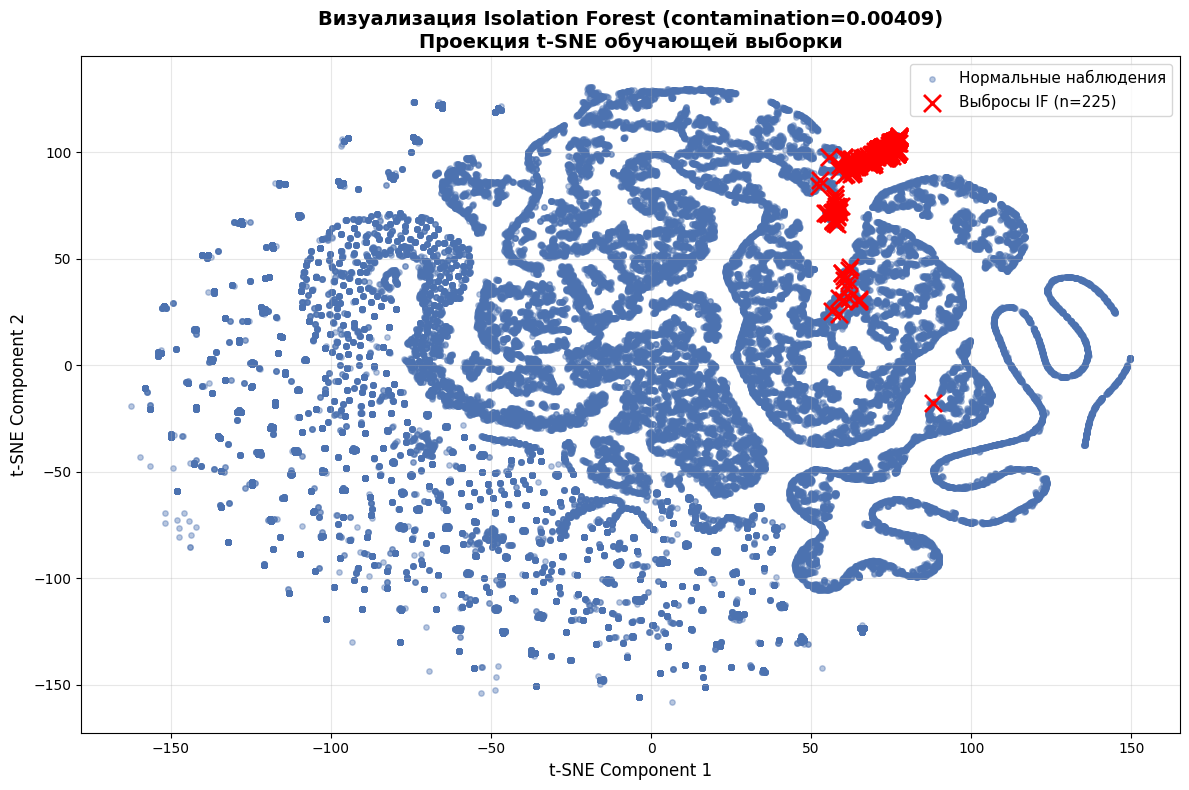


Статистика детекции Isolation Forest:
Всего наблюдений: 54835
Выявлено аномалий: 225 (0.41%)
Параметр contamination: 0.004091224489795918


In [77]:
X_vis = X_train.copy()
y_vis = y_train.copy()
mask_vis = outlier_mask_train

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=-1)
X_2d = tsne.fit_transform(X_vis)
fig, ax = plt.subplots(figsize=(12, 8))

normal_mask = ~mask_vis
ax.scatter(X_2d[normal_mask, 0], X_2d[normal_mask, 1], 
           c='#4C72B0', alpha=0.4, s=15, label='Нормальные наблюдения')

anomaly_mask = mask_vis
if anomaly_mask.any():
    ax.scatter(X_2d[anomaly_mask, 0], X_2d[anomaly_mask, 1], 
               c='red', marker='x', s=150, linewidths=2, zorder=5, 
               label=f'Выбросы IF (n={anomaly_mask.sum()})')

ax.set_title(f'Визуализация Isolation Forest (contamination={best_cont:.5f})\nПроекция t-SNE обучающей выборки', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()
print(f"Статистика детекции Isolation Forest:")
print(f"Всего наблюдений: {len(y_vis)}")
print(f"Выявлено аномалий: {anomaly_mask.sum()} ({anomaly_mask.sum()/len(y_vis)*100:.2f}%)")
print(f"Параметр contamination: {best_cont}")

Визуализация через t-SNE наглядно демонстрирует структуру данных после применения метода Isolation Forest. Метод детекции выбросов с параметром чувствительности contamination, подобранным по критерию максимизации $R^2$ на кросс-валидации тренировочной выборки, идентифицировал 225 объектов, которые отмечены красными крестами на графике выше. Эти точки сгруппировались отдельно от основной массы данных, что говорит о нетипичном поведении этих пользователей. Несмотря на способность алгоритма выявлять локальные аномалии в пространстве признаков, их удаление не привело к улучшению метрик качества модели (значения вычисленных метрик приведены ниже), что подтверждает однородность основной массы данных и достаточность более простых методов предобработки. Это говорит о том, что применение Isolation Forest в данном пайплайне оказалось избыточным. 

In [78]:
scaler_iso = StandardScaler()
X_train_iso_scaled = scaler_iso.fit_transform(X_train_iso)
X_test_iso_scaled = scaler_iso.transform(X_test)

In [79]:
X_ready = X_train_iso_scaled
y_ready = y_train_iso

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    model = Ridge(alpha=alpha)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(model, X_ready, y_ready, cv=cv, scoring='r2', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_alpha = study.best_params['alpha']
print(f"Лучший alpha: {best_alpha:.4f}")
print(f"R² на кросс-валидации: {study.best_value:.4f}")

[I 2026-06-12 18:01:42,132] A new study created in memory with name: no-name-fe929950-5ede-43e8-b030-b23b7669903f
Best trial: 0. Best value: 0.812105:   2%|▏         | 1/50 [00:00<00:11,  4.18it/s]

[I 2026-06-12 18:01:42,379] Trial 0 finished with value: 0.812105008304745 and parameters: {'alpha': 0.03148911647956861}. Best is trial 0 with value: 0.812105008304745.


Best trial: 1. Best value: 0.812119:   4%|▍         | 2/50 [00:00<00:11,  4.14it/s]

[I 2026-06-12 18:01:42,627] Trial 1 finished with value: 0.8121188739760882 and parameters: {'alpha': 6.351221010640703}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:   6%|▌         | 3/50 [00:00<00:14,  3.18it/s]

[I 2026-06-12 18:01:43,026] Trial 2 finished with value: 0.8121068056191033 and parameters: {'alpha': 0.8471801418819978}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:   8%|▊         | 4/50 [00:01<00:12,  3.56it/s]

[I 2026-06-12 18:01:43,258] Trial 3 finished with value: 0.8121054858215283 and parameters: {'alpha': 0.24810409748678125}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:  10%|█         | 5/50 [00:01<00:12,  3.72it/s]

[I 2026-06-12 18:01:43,503] Trial 4 finished with value: 0.8121049481535012 and parameters: {'alpha': 0.004207988669606638}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:  12%|█▏        | 6/50 [00:01<00:11,  3.93it/s]

[I 2026-06-12 18:01:43,730] Trial 5 finished with value: 0.8121049481514403 and parameters: {'alpha': 0.004207053950287938}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:  14%|█▍        | 7/50 [00:01<00:10,  4.08it/s]

[I 2026-06-12 18:01:43,955] Trial 6 finished with value: 0.8121049426399027 and parameters: {'alpha': 0.0017073967431528124}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:  16%|█▌        | 8/50 [00:02<00:09,  4.24it/s]

[I 2026-06-12 18:01:44,171] Trial 7 finished with value: 0.8121113526919264 and parameters: {'alpha': 2.9154431891537547}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:  18%|█▊        | 9/50 [00:02<00:11,  3.60it/s]

[I 2026-06-12 18:01:44,525] Trial 8 finished with value: 0.8121054983350297 and parameters: {'alpha': 0.2537815508265665}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 1. Best value: 0.812119:  20%|██        | 10/50 [00:02<00:12,  3.27it/s]

[I 2026-06-12 18:01:44,904] Trial 9 finished with value: 0.8121064366817251 and parameters: {'alpha': 0.679657809075816}. Best is trial 1 with value: 0.8121188739760882.


Best trial: 10. Best value: 0.812123:  22%|██▏       | 11/50 [00:03<00:13,  2.98it/s]

[I 2026-06-12 18:01:45,314] Trial 10 finished with value: 0.8121230765351631 and parameters: {'alpha': 8.279028516239514}. Best is trial 10 with value: 0.8121230765351631.


Best trial: 10. Best value: 0.812123:  24%|██▍       | 12/50 [00:03<00:11,  3.28it/s]

[I 2026-06-12 18:01:45,545] Trial 11 finished with value: 0.8121167699964197 and parameters: {'alpha': 5.388253252984512}. Best is trial 10 with value: 0.8121230765351631.


Best trial: 10. Best value: 0.812123:  26%|██▌       | 13/50 [00:03<00:10,  3.51it/s]

[I 2026-06-12 18:01:45,787] Trial 12 finished with value: 0.8121214963988397 and parameters: {'alpha': 7.553503645583182}. Best is trial 10 with value: 0.8121230765351631.


Best trial: 10. Best value: 0.812123:  28%|██▊       | 14/50 [00:03<00:09,  3.62it/s]

[I 2026-06-12 18:01:46,045] Trial 13 finished with value: 0.8121085755486817 and parameters: {'alpha': 1.6514533655515913}. Best is trial 10 with value: 0.8121230765351631.


Best trial: 14. Best value: 0.812125:  30%|███       | 15/50 [00:04<00:09,  3.77it/s]

[I 2026-06-12 18:01:46,276] Trial 14 finished with value: 0.8121250844552632 and parameters: {'alpha': 9.202160576733972}. Best is trial 14 with value: 0.8121250844552632.


Best trial: 14. Best value: 0.812125:  32%|███▏      | 16/50 [00:04<00:08,  3.94it/s]

[I 2026-06-12 18:01:46,513] Trial 15 finished with value: 0.8121049912179666 and parameters: {'alpha': 0.023739423955292552}. Best is trial 14 with value: 0.8121250844552632.


Best trial: 14. Best value: 0.812125:  34%|███▍      | 17/50 [00:04<00:08,  4.03it/s]

[I 2026-06-12 18:01:46,743] Trial 16 finished with value: 0.8121089607689674 and parameters: {'alpha': 1.8266344041193754}. Best is trial 14 with value: 0.8121250844552632.


Best trial: 14. Best value: 0.812125:  36%|███▌      | 18/50 [00:04<00:07,  4.07it/s]

[I 2026-06-12 18:01:46,986] Trial 17 finished with value: 0.8121052583878484 and parameters: {'alpha': 0.14492473635015288}. Best is trial 14 with value: 0.8121250844552632.


Best trial: 14. Best value: 0.812125:  38%|███▊      | 19/50 [00:05<00:07,  4.16it/s]

[I 2026-06-12 18:01:47,214] Trial 18 finished with value: 0.8121068191495237 and parameters: {'alpha': 0.853324688983006}. Best is trial 14 with value: 0.8121250844552632.


Best trial: 19. Best value: 0.812126:  40%|████      | 20/50 [00:05<00:07,  4.17it/s]

[I 2026-06-12 18:01:47,451] Trial 19 finished with value: 0.8121263685213205 and parameters: {'alpha': 9.793203726045522}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 19. Best value: 0.812126:  42%|████▏     | 21/50 [00:05<00:06,  4.17it/s]

[I 2026-06-12 18:01:47,691] Trial 20 finished with value: 0.8121050698786784 and parameters: {'alpha': 0.05941668965297967}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 19. Best value: 0.812126:  44%|████▍     | 22/50 [00:05<00:06,  4.18it/s]

[I 2026-06-12 18:01:47,926] Trial 21 finished with value: 0.8121224597070121 and parameters: {'alpha': 7.995711921718729}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 19. Best value: 0.812126:  46%|████▌     | 23/50 [00:06<00:06,  4.21it/s]

[I 2026-06-12 18:01:48,159] Trial 22 finished with value: 0.8121113031342209 and parameters: {'alpha': 2.8928657015313313}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 19. Best value: 0.812126:  48%|████▊     | 24/50 [00:06<00:06,  4.26it/s]

[I 2026-06-12 18:01:48,390] Trial 23 finished with value: 0.8121252649368234 and parameters: {'alpha': 9.285201475298665}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 19. Best value: 0.812126:  50%|█████     | 25/50 [00:06<00:05,  4.17it/s]

[I 2026-06-12 18:01:48,646] Trial 24 finished with value: 0.8121127078761958 and parameters: {'alpha': 3.5331452097559457}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 19. Best value: 0.812126:  52%|█████▏    | 26/50 [00:06<00:06,  3.53it/s]

[I 2026-06-12 18:01:49,025] Trial 25 finished with value: 0.8121080094790519 and parameters: {'alpha': 1.3941165518456238}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 19. Best value: 0.812126:  54%|█████▍    | 27/50 [00:07<00:06,  3.64it/s]

[I 2026-06-12 18:01:49,282] Trial 26 finished with value: 0.8121057790665563 and parameters: {'alpha': 0.38116433359926216}. Best is trial 19 with value: 0.8121263685213205.


Best trial: 27. Best value: 0.812127:  56%|█████▌    | 28/50 [00:07<00:05,  3.85it/s]

[I 2026-06-12 18:01:49,504] Trial 27 finished with value: 0.8121266599991099 and parameters: {'alpha': 9.92744430814271}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  58%|█████▊    | 29/50 [00:07<00:05,  3.88it/s]

[I 2026-06-12 18:01:49,759] Trial 28 finished with value: 0.8121130749413957 and parameters: {'alpha': 3.7005581994758074}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  60%|██████    | 30/50 [00:07<00:05,  3.86it/s]

[I 2026-06-12 18:01:50,021] Trial 29 finished with value: 0.8121050171747543 and parameters: {'alpha': 0.035512137719444455}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  62%|██████▏   | 31/50 [00:08<00:04,  3.98it/s]

[I 2026-06-12 18:01:50,254] Trial 30 finished with value: 0.8121090176574267 and parameters: {'alpha': 1.8525087835738567}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  64%|██████▍   | 32/50 [00:08<00:04,  4.03it/s]

[I 2026-06-12 18:01:50,498] Trial 31 finished with value: 0.8121265720242425 and parameters: {'alpha': 9.886924363460965}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  66%|██████▌   | 33/50 [00:08<00:04,  4.10it/s]

[I 2026-06-12 18:01:50,730] Trial 32 finished with value: 0.8121150207113954 and parameters: {'alpha': 4.588724379493519}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  68%|██████▊   | 34/50 [00:08<00:03,  4.15it/s]

[I 2026-06-12 18:01:50,964] Trial 33 finished with value: 0.8121145937161147 and parameters: {'alpha': 4.393712884432456}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  70%|███████   | 35/50 [00:09<00:03,  4.14it/s]

[I 2026-06-12 18:01:51,208] Trial 34 finished with value: 0.8121257313093952 and parameters: {'alpha': 9.499832920910258}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  72%|███████▏  | 36/50 [00:09<00:03,  4.18it/s]

[I 2026-06-12 18:01:51,445] Trial 35 finished with value: 0.8121072084521532 and parameters: {'alpha': 1.0301431431083539}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  74%|███████▍  | 37/50 [00:09<00:03,  4.18it/s]

[I 2026-06-12 18:01:51,682] Trial 36 finished with value: 0.8121101637794302 and parameters: {'alpha': 2.374017178580072}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  76%|███████▌  | 38/50 [00:09<00:02,  4.19it/s]

[I 2026-06-12 18:01:51,919] Trial 37 finished with value: 0.8121060320355662 and parameters: {'alpha': 0.4959713565737128}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  78%|███████▊  | 39/50 [00:10<00:02,  4.08it/s]

[I 2026-06-12 18:01:52,162] Trial 38 finished with value: 0.8121049619526209 and parameters: {'alpha': 0.010466369837118256}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 27. Best value: 0.812127:  80%|████████  | 40/50 [00:10<00:02,  4.30it/s]

[I 2026-06-12 18:01:52,380] Trial 39 finished with value: 0.8121171464505952 and parameters: {'alpha': 5.560445893817445}. Best is trial 27 with value: 0.8121266599991099.


Best trial: 40. Best value: 0.812127:  82%|████████▏ | 41/50 [00:10<00:02,  4.32it/s]

[I 2026-06-12 18:01:52,609] Trial 40 finished with value: 0.8121266904073581 and parameters: {'alpha': 9.941450502972573}. Best is trial 40 with value: 0.8121266904073581.


Best trial: 40. Best value: 0.812127:  84%|████████▍ | 42/50 [00:10<00:01,  4.36it/s]

[I 2026-06-12 18:01:52,820] Trial 41 finished with value: 0.8121169438388043 and parameters: {'alpha': 5.467764170217338}. Best is trial 40 with value: 0.8121266904073581.


Best trial: 40. Best value: 0.812127:  86%|████████▌ | 43/50 [00:11<00:01,  3.84it/s]

[I 2026-06-12 18:01:53,164] Trial 42 finished with value: 0.8121114056474701 and parameters: {'alpha': 2.93956953927343}. Best is trial 40 with value: 0.8121266904073581.


Best trial: 40. Best value: 0.812127:  88%|████████▊ | 44/50 [00:11<00:01,  3.55it/s]

[I 2026-06-12 18:01:53,490] Trial 43 finished with value: 0.8121266060583349 and parameters: {'alpha': 9.902599666633746}. Best is trial 40 with value: 0.8121266904073581.


Best trial: 40. Best value: 0.812127:  90%|█████████ | 45/50 [00:11<00:01,  3.42it/s]

[I 2026-06-12 18:01:53,815] Trial 44 finished with value: 0.8121159288404176 and parameters: {'alpha': 5.003669837757073}. Best is trial 40 with value: 0.8121266904073581.


Best trial: 45. Best value: 0.812127:  92%|█████████▏| 46/50 [00:11<00:01,  3.63it/s]

[I 2026-06-12 18:01:54,046] Trial 45 finished with value: 0.8121266991641422 and parameters: {'alpha': 9.945483979496762}. Best is trial 45 with value: 0.8121266991641422.


Best trial: 45. Best value: 0.812127:  94%|█████████▍| 47/50 [00:12<00:00,  3.37it/s]

[I 2026-06-12 18:01:54,401] Trial 46 finished with value: 0.8121190341398631 and parameters: {'alpha': 6.424585444995903}. Best is trial 45 with value: 0.8121266991641422.


Best trial: 45. Best value: 0.812127:  96%|█████████▌| 48/50 [00:12<00:00,  3.32it/s]

[I 2026-06-12 18:01:54,713] Trial 47 finished with value: 0.8121075094327876 and parameters: {'alpha': 1.1668796565450918}. Best is trial 45 with value: 0.8121266991641422.


Best trial: 45. Best value: 0.812127:  98%|█████████▊| 49/50 [00:12<00:00,  3.61it/s]

[I 2026-06-12 18:01:54,932] Trial 48 finished with value: 0.8121097942125475 and parameters: {'alpha': 2.205810694217755}. Best is trial 45 with value: 0.8121266991641422.


Best trial: 45. Best value: 0.812127: 100%|██████████| 50/50 [00:13<00:00,  3.84it/s]

[I 2026-06-12 18:01:55,151] Trial 49 finished with value: 0.8121186616892212 and parameters: {'alpha': 6.253994073305037}. Best is trial 45 with value: 0.8121266991641422.
Лучший alpha: 9.9455
R² на кросс-валидации: 0.8121


In [80]:
model_linreg_iso = LinearRegression()
model_ridge_iso = Ridge(alpha=best_alpha)

print("Обучение модели линейной регрессии")
model_linreg_iso.fit(X_train_iso_scaled, y_train_iso)
print("Модель обучена")

print("Обучение модели Ridge-регрессии")
model_ridge_iso.fit(X_train_iso_scaled, y_train_iso)
print("Модель обучена")


models = {
    "linreg": model_linreg_iso,
    "ridge": model_ridge_iso
    }

print("Полученные коэффициенты моделей:")

for name, model_cat in models.items():
    print(f"model {name}: {model_cat.coef_}\n")

Обучение модели линейной регрессии
Модель обучена
Обучение модели Ridge-регрессии
Модель обучена
Полученные коэффициенты моделей:
model linreg: [ 0.08629467  0.10100809 -0.01190256 -0.04918038 -0.06205073  0.01038633
  0.23802418  2.00637409 -0.01128154 -0.00404542 -0.16979672  0.07908864
  0.25585534  0.00785007]

model ridge: [ 0.08622996  0.1010059  -0.0119002  -0.04900426 -0.06140748  0.01044009
  0.23795964  2.00527285 -0.01125536 -0.00411483 -0.16970039  0.07935335
  0.25583883  0.00799224]



In [81]:
y_linreg_iso_train_pred = model_linreg_iso.predict(X_train_iso_scaled)
y_linreg_iso_test_pred = model_linreg_iso.predict(X_test_iso_scaled)

y_ridge_iso_train_pred = model_ridge_iso.predict(X_train_iso_scaled)
y_ridge_iso_test_pred = model_ridge_iso.predict(X_test_iso_scaled)

In [82]:
train_linreg_iso_metrics = evaluate_model(y_train_iso, y_linreg_iso_train_pred, "Обучающая выборка", "linreg", "ISO")
train_ridge_iso_metrics = evaluate_model(y_train_iso, y_ridge_iso_train_pred, "Обучающая выборка", "ridge", "ISO")

test_linreg_iso_metrics = evaluate_model(y_test, y_linreg_iso_test_pred, "Тестовая выборка (с наличием выбросов)", "linreg", "ISO")
test_ridge_iso_metrics = evaluate_model(y_test, y_ridge_iso_test_pred, "Тестовая выборка (с наличием выбросов)", "ridge", "ISO")


МЕТРИКИ КАЧЕСТВА linreg, детецкия выбросов: ISO

Обучающая выборка:
  R² (коэффициент детерминации): 0.8184288796671123
  MSE (среднеквадратичная ошибка): 1.0019939962851838
  RMSE (корень из MSE): 1.0009965016348379
  MAE (средняя абсолютная ошибка): 0.6873463702363681


МЕТРИКИ КАЧЕСТВА ridge, детецкия выбросов: ISO

Обучающая выборка:
  R² (коэффициент детерминации): 0.8184288045723253
  MSE (среднеквадратичная ошибка): 1.001994410693189
  RMSE (корень из MSE): 1.0009967086325455
  MAE (средняя абсолютная ошибка): 0.6873630437945296


МЕТРИКИ КАЧЕСТВА linreg, детецкия выбросов: ISO

Тестовая выборка (с наличием выбросов):
  R² (коэффициент детерминации): 0.8073757586431075
  MSE (среднеквадратичная ошибка): 1.0695212990910195
  RMSE (корень из MSE): 1.0341766285751286
  MAE (средняя абсолютная ошибка): 0.6975843764237065


МЕТРИКИ КАЧЕСТВА ridge, детецкия выбросов: ISO

Тестовая выборка (с наличием выбросов):
  R² (коэффициент детерминации): 0.8073798396717919
  MSE (среднеквадрати

In [83]:
results = []

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'Нет',
    'Train R²': train_linreg_metrics['r2'],
    'Test R²': test_linreg_metrics['r2'],
    'Test RMSE': test_linreg_metrics['rmse'],
    'Test MAE': test_linreg_metrics['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'Нет',
    'Train R²': train_ridge_metrics['r2'],
    'Test R²': test_ridge_metrics['r2'],
    'Test RMSE': test_ridge_metrics['rmse'],
    'Test MAE': test_ridge_metrics['mae']
})

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'IQR + ISO',
    'Train R²': train_linreg_iso_metrics['r2'],
    'Test R²': test_linreg_iso_metrics['r2'],
    'Test RMSE': test_linreg_iso_metrics['rmse'],
    'Test MAE': test_linreg_iso_metrics['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'IQR + ISO',
    'Train R²': train_ridge_iso_metrics['r2'],
    'Test R²': test_ridge_iso_metrics['r2'],
    'Test RMSE': test_ridge_iso_metrics['rmse'],
    'Test MAE': test_ridge_iso_metrics['mae']
})

df_results = pd.DataFrame(results)
print(df_results[['Модель', 'Детекция', 'Train R²', 'Test R²', 'Test RMSE', 'Test MAE']].to_string(index=False))
best_idx = df_results['Test R²'].idxmax()
print(f"\n✓ Лучшая модель по Test R²: {df_results.loc[best_idx, 'Модель']} + {df_results.loc[best_idx, 'Детекция']} (R² = {df_results.loc[best_idx, 'Test R²']:.4f})")

           Модель  Детекция  Train R²  Test R²  Test RMSE  Test MAE
Linear Regression       Нет  0.818559 0.807690   1.033333  0.698088
 Ridge Regression       Нет  0.818551 0.807699   1.033309  0.698268
Linear Regression IQR + ISO  0.818429 0.807376   1.034177  0.697584
 Ridge Regression IQR + ISO  0.818429 0.807380   1.034166  0.697597

✓ Лучшая модель по Test R²: Ridge Regression + Нет (R² = 0.8077)



КОЭФФИЦИЕНТЫ МОДЕЛИ Linreg (Iso):
                      feature  coefficient
           unique_event_types     2.006374
              percentage_boss     0.255855
                  active_days     0.238024
                   total_boss    -0.169797
avg_interval_between_sessions     0.101008
      days_since_installation     0.086295
               percentage_ads     0.079089
                 unique_items    -0.062051
             max_weapon_level    -0.049180
                  user_rating    -0.011903
           total_events_count    -0.011282
              unique_sessions     0.010386
                   has_rating     0.007850
                    total_ads    -0.004045

Свободный член (intercept): 6.13


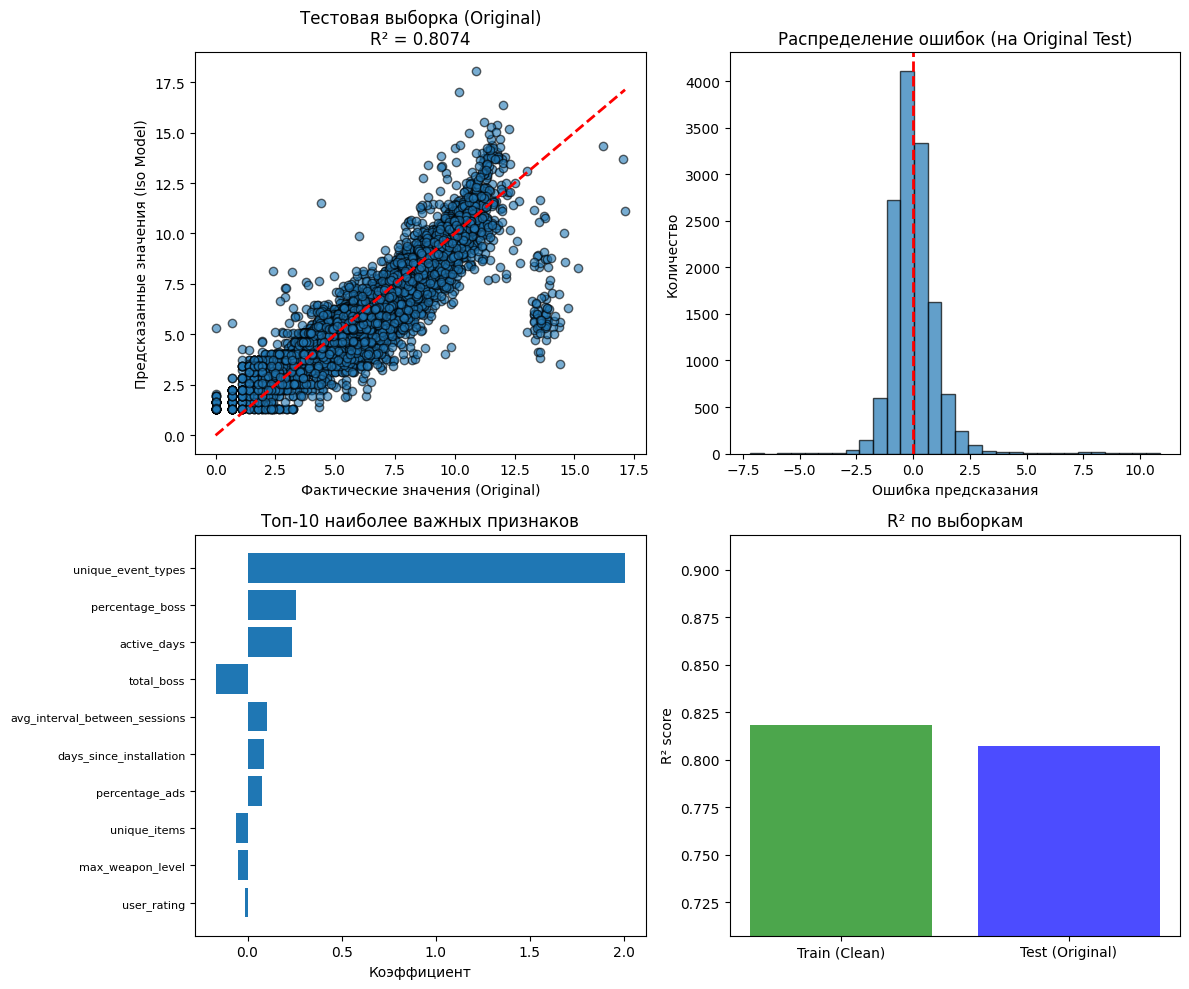

In [84]:
print("\n" + "="*50)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ Linreg (Iso):")
print("="*50)

coefficients_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_linreg_iso.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(coefficients_df.to_string(index=False))
print(f"\nСвободный член (intercept): {model_linreg_iso.intercept_:.2f}")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(y_test, y_linreg_iso_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения (Original)')
axes[0, 0].set_ylabel('Предсказанные значения (Iso Model)')
axes[0, 0].set_title(f'Тестовая выборка (Original)\nR² = {test_linreg_iso_metrics["r2"]:.4f}')

errors = y_test - y_linreg_iso_test_pred
axes[0, 1].hist(errors, bins=30, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Ошибка предсказания')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_title('Распределение ошибок (на Original Test)')

top_features = coefficients_df.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['coefficient'].values)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['feature'].values, rotation=0, fontsize=8)
axes[1, 0].set_xlabel('Коэффициент')
axes[1, 0].set_title('Топ-10 наиболее важных признаков')
axes[1, 0].invert_yaxis()

datasets = ['Train (Clean)', 'Test (Original)']
r2_scores = [train_linreg_iso_metrics['r2'], test_linreg_iso_metrics['r2']]
colors = ['green', 'blue']
axes[1, 1].bar(datasets, r2_scores, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² score')
axes[1, 1].set_title('R² по выборкам')
axes[1, 1].set_ylim([min(r2_scores) - 0.1, max(r2_scores) + 0.1])

plt.tight_layout()
plt.show()

КОЭФФИЦИЕНТЫ МОДЕЛИ Ridge (Iso):
                      feature  coefficient
           unique_event_types     2.005273
              percentage_boss     0.255839
                  active_days     0.237960
                   total_boss    -0.169700
avg_interval_between_sessions     0.101006
      days_since_installation     0.086230
               percentage_ads     0.079353
                 unique_items    -0.061407
             max_weapon_level    -0.049004
                  user_rating    -0.011900
           total_events_count    -0.011255
              unique_sessions     0.010440
                   has_rating     0.007992
                    total_ads    -0.004115

Свободный член (intercept): 6.13


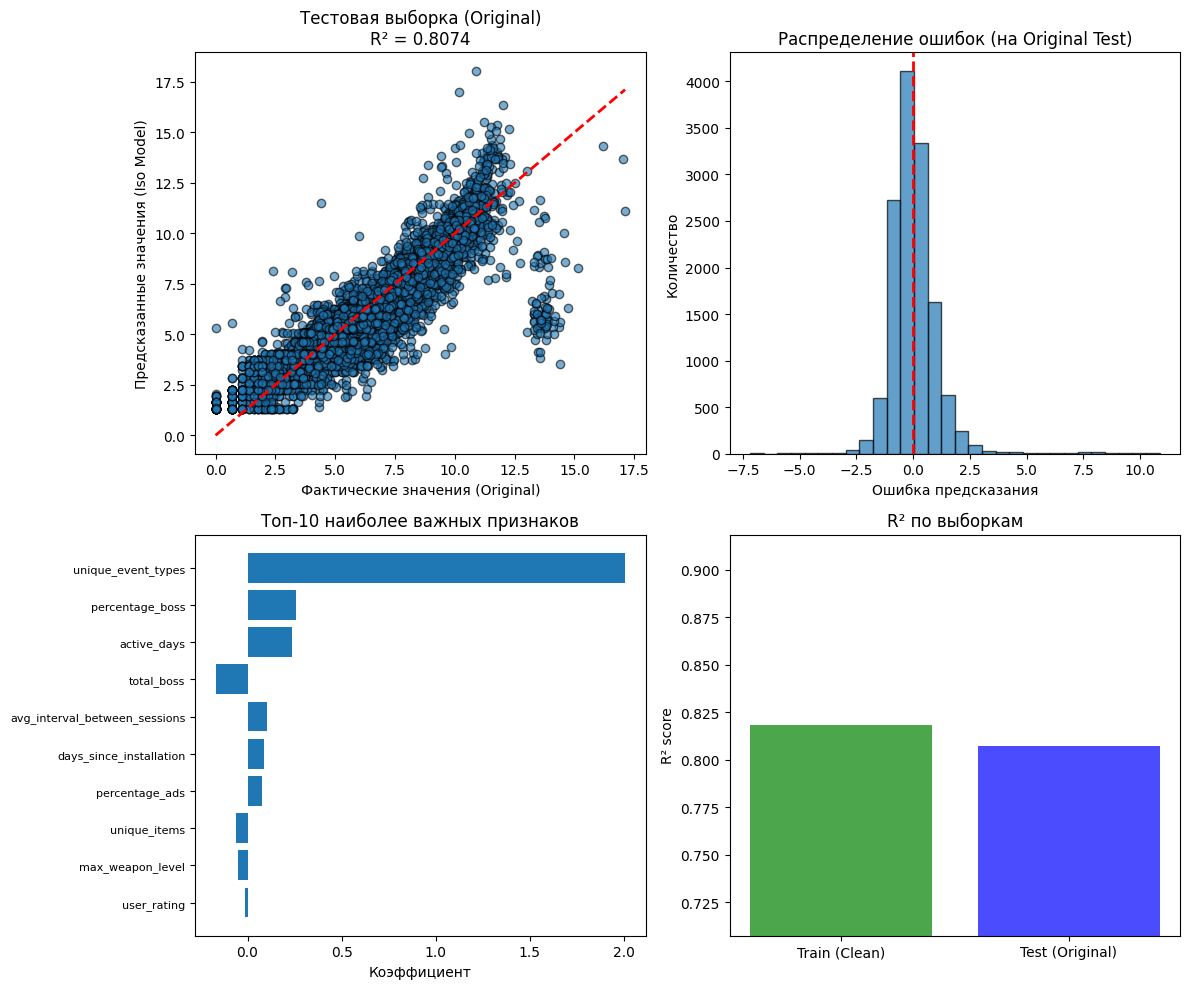

In [85]:
print("КОЭФФИЦИЕНТЫ МОДЕЛИ Ridge (Iso):")

coefficients_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_ridge_iso.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(coefficients_df.to_string(index=False))
print()
print(f"Свободный член (intercept): {model_ridge_iso.intercept_:.2f}")



fig, axes = plt.subplots(2, 2, figsize=(12, 10))


axes[0, 0].scatter(y_test, y_ridge_iso_test_pred, alpha=0.6, edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения (Original)')
axes[0, 0].set_ylabel('Предсказанные значения (Iso Model)')
axes[0, 0].set_title(f'Тестовая выборка (Original)\nR² = {test_ridge_iso_metrics["r2"]:.4f}')


errors = y_test - y_ridge_iso_test_pred
axes[0, 1].hist(errors, bins=30, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Ошибка предсказания')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_title('Распределение ошибок (на Original Test)')


top_features = coefficients_df.head(10)
axes[1, 0].barh(range(len(top_features)), top_features['coefficient'].values)
axes[1, 0].set_yticks(range(len(top_features)))
axes[1, 0].set_yticklabels(top_features['feature'].values, rotation=0, fontsize=8)
axes[1, 0].set_xlabel('Коэффициент')
axes[1, 0].set_title('Топ-10 наиболее важных признаков')
axes[1, 0].invert_yaxis()


datasets = ['Train (Clean)', 'Test (Original)']
r2_scores = [train_ridge_iso_metrics['r2'], test_ridge_iso_metrics['r2']]
colors = ['green', 'blue']
axes[1, 1].bar(datasets, r2_scores, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R² score')
axes[1, 1].set_title('R² по выборкам')
axes[1, 1].set_ylim([min(r2_scores) - 0.1, max(r2_scores) + 0.1])

plt.tight_layout()
plt.show()

### Метод детекции LOF

c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.005: Test R² = 0.8077 | CV R² = 0.8116 | Удалено: 257 | Осталось: 54578


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.008: Test R² = 0.8076 | CV R² = 0.8076 | Удалено: 386 | Осталось: 54449


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.010: Test R² = 0.8076 | CV R² = 0.8093 | Удалено: 538 | Осталось: 54297


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.013: Test R² = 0.8076 | CV R² = 0.8112 | Удалено: 652 | Осталось: 54183


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.015: Test R² = 0.8076 | CV R² = 0.8076 | Удалено: 839 | Осталось: 53996


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.018: Test R² = 0.8076 | CV R² = 0.8095 | Удалено: 939 | Осталось: 53896


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.021: Test R² = 0.8076 | CV R² = 0.8087 | Удалено: 1094 | Осталось: 53741


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.023: Test R² = 0.8076 | CV R² = 0.8113 | Удалено: 1259 | Осталось: 53576


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.026: Test R² = 0.8076 | CV R² = 0.8113 | Удалено: 1259 | Осталось: 53576


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.028: Test R² = 0.8076 | CV R² = 0.8096 | Удалено: 1429 | Осталось: 53406


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.031: Test R² = 0.8076 | CV R² = 0.8071 | Удалено: 1691 | Осталось: 53144


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.033: Test R² = 0.8076 | CV R² = 0.8041 | Удалено: 1824 | Осталось: 53011


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.036: Test R² = 0.8076 | CV R² = 0.8090 | Удалено: 1975 | Осталось: 52860


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.039: Test R² = 0.8104 | CV R² = 0.8183 | Удалено: 2118 | Осталось: 52717


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.041: Test R² = 0.8108 | CV R² = 0.8212 | Удалено: 2260 | Осталось: 52575


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.044: Test R² = 0.8105 | CV R² = 0.8234 | Удалено: 2402 | Осталось: 52433


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.046: Test R² = 0.8104 | CV R² = 0.8252 | Удалено: 2544 | Осталось: 52291


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.049: Test R² = 0.8104 | CV R² = 0.8263 | Удалено: 2685 | Осталось: 52150


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.052: Test R² = 0.8102 | CV R² = 0.8282 | Удалено: 2827 | Осталось: 52008


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.054: Test R² = 0.8102 | CV R² = 0.8296 | Удалено: 2969 | Осталось: 51866


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.057: Test R² = 0.8101 | CV R² = 0.8311 | Удалено: 3111 | Осталось: 51724


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.059: Test R² = 0.8100 | CV R² = 0.8317 | Удалено: 3253 | Осталось: 51582


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.062: Test R² = 0.8100 | CV R² = 0.8318 | Удалено: 3395 | Осталось: 51440


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.064: Test R² = 0.8099 | CV R² = 0.8324 | Удалено: 3536 | Осталось: 51299


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.067: Test R² = 0.8098 | CV R² = 0.8329 | Удалено: 3678 | Осталось: 51157


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.070: Test R² = 0.8098 | CV R² = 0.8338 | Удалено: 3820 | Осталось: 51015


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.072: Test R² = 0.8097 | CV R² = 0.8342 | Удалено: 3962 | Осталось: 50873


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.075: Test R² = 0.8097 | CV R² = 0.8348 | Удалено: 4104 | Осталось: 50731


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


contamination=0.077: Test R² = 0.8098 | CV R² = 0.8351 | Удалено: 4245 | Осталось: 50590


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
C:\Users\Viktor\AppData\Local\Temp\ipykernel_3376\3857806600.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right')


contamination=0.080: Test R² = 0.8098 | CV R² = 0.8356 | Удалено: 4387 | Осталось: 50448

Оптимальный contamination по сетке: 0.080 (CV R² = 0.8356)


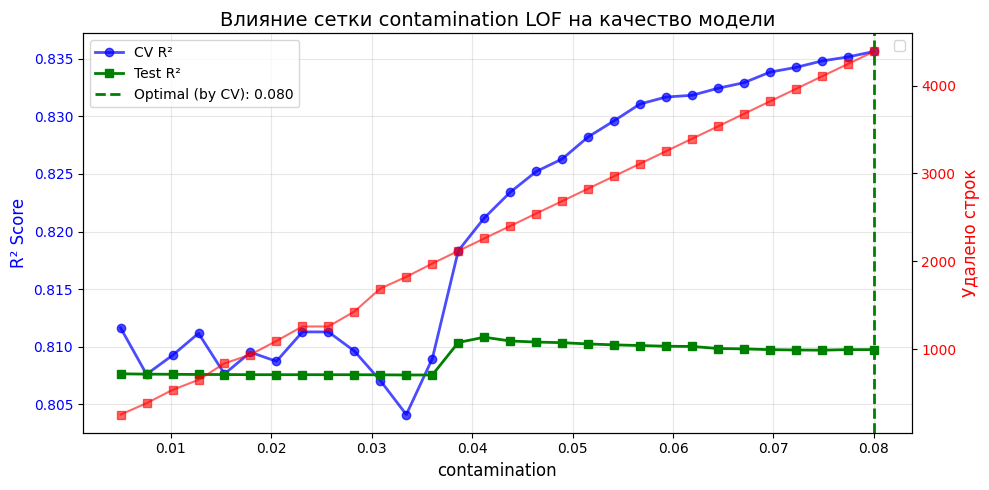

In [86]:
X_base = X_train.copy()
y_base = y_train.copy()

contamination_grid = np.linspace(0.005, 0.08, 30)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
best_cont = None
best_cv_r2 = -np.inf
results_lof = []

for cont in contamination_grid:
    lof = LocalOutlierFactor(n_neighbors=20, contamination=cont)
    outlier_mask = lof.fit_predict(X_base) == -1
    X_filtered = X_base[~outlier_mask]
    y_filtered = y_base[~outlier_mask]
    if len(X_filtered) < 200:
        continue
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filtered)
    cv_scores = cross_val_score(Ridge(alpha=1.0), X_scaled, y_filtered, cv=cv, scoring='r2')
    mean_cv_r2 = cv_scores.mean()
    X_test_scaled = scaler.transform(X_test)
    model = Ridge(alpha=1.0)
    model.fit(X_scaled, y_filtered)
    y_pred = model.predict(X_test_scaled)
    test_r2 = r2_score(y_test, y_pred)
    
    results_lof.append({
        'contamination': cont,
        'удалено': int(outlier_mask.sum()),
        'осталось': len(X_filtered),
        'test_r2': test_r2,
        'cv_r2': mean_cv_r2
    })
    
    print(f"contamination={cont:.3f}: Test R² = {test_r2:.4f} | CV R² = {mean_cv_r2:.4f} | Удалено: {outlier_mask.sum()} | Осталось: {len(X_filtered)}")
    
    if mean_cv_r2 > best_cv_r2:
        best_cv_r2 = mean_cv_r2
        best_cont = cont

print()
print(f"Оптимальный contamination по сетке: {best_cont:.3f} (CV R² = {best_cv_r2:.4f})")

df_lof = pd.DataFrame(results_lof)
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_lof['contamination'], df_lof['cv_r2'], 'b-o', label='CV R²', linewidth=2, alpha=0.7)
ax1.plot(df_lof['contamination'], df_lof['test_r2'], 'g-s', label='Test R²', linewidth=2)

ax1.set_xlabel('contamination', fontsize=12)
ax1.set_ylabel('R² Score', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_lof['contamination'], df_lof['удалено'], 'r-s', alpha=0.6)
ax2.set_ylabel('Удалено строк', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Влияние сетки contamination LOF на качество модели', fontsize=14)
ax1.axvline(best_cont, color='green', linestyle='--', linewidth=2, label=f'Optimal (by CV): {best_cont:.3f}')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [87]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=best_cont)
outlier_mask_lof = lof.fit_predict(X_train) == -1

print(f"МЕТОД: Local Outlier Factor после совместного исопльзования методов очистки IQR и ISO")
print(f"Найдено новых выбросов: {outlier_mask_lof.sum()} из {len(y_train)}")
print(f"Процент выбросов: {outlier_mask_lof.sum() / len(y_train) * 100:.2f}%")

МЕТОД: Local Outlier Factor после совместного исопльзования методов очистки IQR и ISO
Найдено новых выбросов: 4387 из 54835
Процент выбросов: 8.00%


c:\Users\Viktor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


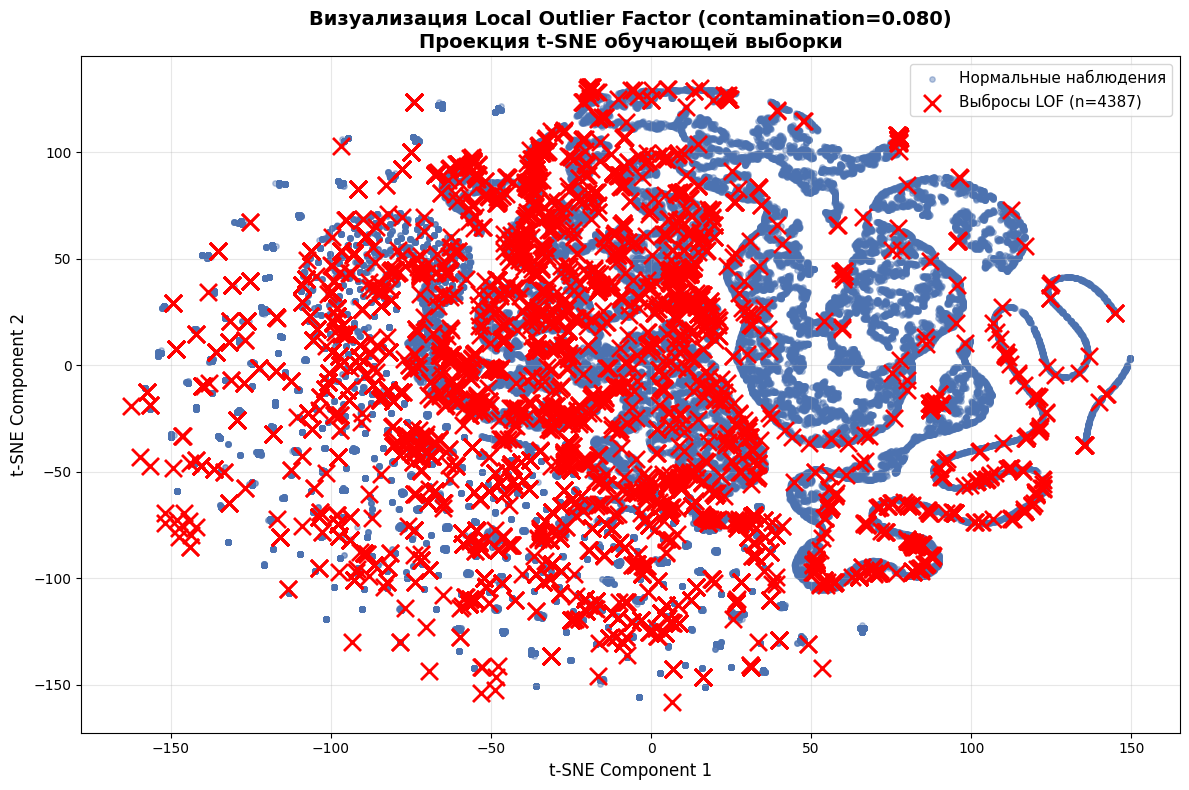

   Всего наблюдений: 54835
   Выявлено аномалий: 4387 (8.00%)
   Параметр contamination: 0.08


In [88]:
X_vis = X_train.copy()
y_vis = y_train.copy()
mask_vis = outlier_mask_lof

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=1)
X_2d = tsne.fit_transform(X_vis)

fig, ax = plt.subplots(figsize=(12, 8))
normal_mask = ~mask_vis
ax.scatter(X_2d[normal_mask, 0], X_2d[normal_mask, 1], c='#4C72B0', alpha=0.4, s=15, label='Нормальные наблюдения')
anomaly_mask = mask_vis
if anomaly_mask.any():
    ax.scatter(X_2d[anomaly_mask, 0], X_2d[anomaly_mask, 1], 
               c='red', marker='x', s=150, linewidths=2, zorder=5, 
               label=f'Выбросы LOF (n={anomaly_mask.sum()})')

ax.set_title(f'Визуализация Local Outlier Factor (contamination={best_cont:.3f})\nПроекция t-SNE обучающей выборки', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"   Всего наблюдений: {len(y_vis)}")
print(f"   Выявлено аномалий: {anomaly_mask.sum()} ({anomaly_mask.sum()/len(y_vis)*100:.2f}%)")
print(f"   Параметр contamination: {best_cont}")

Визуализация на основе t-SNE демонстрирует, что метод Local Outlier Factor (LOF) выявляет локальные аномалии в многомерном пространстве признаков: выбросы (красные крестики) располагаются преимущественно в зонах с низкой плотностью, где наблюдения значительно отличаются от своих соседей. Удаление 4387 объектов при параметре $contamination=0.080$, подобранном по критерию максимизации $R^2$ на кросс-валидации тренировочной выборки, позволило очистить данные от пользователей с нетипичным поведением. Это подтверждает, что именно эти скрытые паттерны искажали линейную зависимость, а оптимизация по кросс-валидации помогла найти баланс между удалением выбросов и сохранением полезной информации для обучения модели.

In [89]:
X_train_final = X_train[~outlier_mask_lof]
y_train_final = y_train[~outlier_mask_lof]

In [90]:
X_ready = X_train_final.copy()
y_ready = y_train_final.copy()

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)
    model = Ridge(alpha=alpha)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_final, y_train_final, cv=cv, scoring='r2', n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_alpha = study.best_params['alpha']

[I 2026-06-12 18:06:00,843] A new study created in memory with name: no-name-c9e0f3dc-8ab4-4bd1-a9a4-721bbf942da7
Best trial: 0. Best value: 0.835617:   7%|▋         | 2/30 [00:00<00:02, 13.78it/s]

[I 2026-06-12 18:06:00,914] Trial 0 finished with value: 0.8356168970389838 and parameters: {'alpha': 0.0074593432857265485}. Best is trial 0 with value: 0.8356168970389838.
[I 2026-06-12 18:06:00,989] Trial 1 finished with value: 0.8314503145600292 and parameters: {'alpha': 5.669849511478847}. Best is trial 0 with value: 0.8356168970389838.


Best trial: 0. Best value: 0.835617:   7%|▋         | 2/30 [00:00<00:02, 13.78it/s]

[I 2026-06-12 18:06:01,074] Trial 2 finished with value: 0.834803355012068 and parameters: {'alpha': 0.4570563099801455}. Best is trial 0 with value: 0.8356168970389838.


Best trial: 4. Best value: 0.835617:  13%|█▎        | 4/30 [00:00<00:02, 12.08it/s]

[I 2026-06-12 18:06:01,165] Trial 3 finished with value: 0.8355392380470293 and parameters: {'alpha': 0.09846738873614563}. Best is trial 0 with value: 0.8356168970389838.
[I 2026-06-12 18:06:01,242] Trial 4 finished with value: 0.8356173513478385 and parameters: {'alpha': 0.0006026889128682511}. Best is trial 4 with value: 0.8356173513478385.


Best trial: 4. Best value: 0.835617:  20%|██        | 6/30 [00:00<00:01, 12.82it/s]

[I 2026-06-12 18:06:01,309] Trial 5 finished with value: 0.8356173513469338 and parameters: {'alpha': 0.000602521573620386}. Best is trial 4 with value: 0.8356173513478385.


Best trial: 4. Best value: 0.835617:  27%|██▋       | 8/30 [00:00<00:01, 13.41it/s]

[I 2026-06-12 18:06:01,381] Trial 6 finished with value: 0.8356173473736735 and parameters: {'alpha': 0.00019517224641449495}. Best is trial 4 with value: 0.8356173513478385.
[I 2026-06-12 18:06:01,447] Trial 7 finished with value: 0.8326360451548316 and parameters: {'alpha': 2.1423021757741068}. Best is trial 4 with value: 0.8356173513478385.


Best trial: 4. Best value: 0.835617:  27%|██▋       | 8/30 [00:00<00:01, 13.41it/s]

[I 2026-06-12 18:06:01,514] Trial 8 finished with value: 0.8355352322821791 and parameters: {'alpha': 0.10129197956845731}. Best is trial 4 with value: 0.8356173513478385.


Best trial: 4. Best value: 0.835617:  33%|███▎      | 10/30 [00:00<00:01, 13.98it/s]

[I 2026-06-12 18:06:01,582] Trial 9 finished with value: 0.8350452230802249 and parameters: {'alpha': 0.3470266988650412}. Best is trial 4 with value: 0.8356173513478385.
[I 2026-06-12 18:06:01,652] Trial 10 finished with value: 0.8356172724189308 and parameters: {'alpha': 0.0036035178201071797}. Best is trial 4 with value: 0.8356173513478385.


Best trial: 4. Best value: 0.835617:  40%|████      | 12/30 [00:00<00:01, 14.10it/s]

[I 2026-06-12 18:06:01,721] Trial 11 finished with value: 0.8356173459923479 and parameters: {'alpha': 0.00010359916440554263}. Best is trial 4 with value: 0.8356173513478385.


Best trial: 12. Best value: 0.835617:  47%|████▋     | 14/30 [00:01<00:01, 14.13it/s]

[I 2026-06-12 18:06:01,792] Trial 12 finished with value: 0.8356173515331609 and parameters: {'alpha': 0.0010735378215036783}. Best is trial 12 with value: 0.8356173515331609.
[I 2026-06-12 18:06:01,862] Trial 13 finished with value: 0.8356173442149888 and parameters: {'alpha': 0.0017150762599230278}. Best is trial 12 with value: 0.8356173515331609.


Best trial: 12. Best value: 0.835617:  47%|████▋     | 14/30 [00:01<00:01, 14.13it/s]

[I 2026-06-12 18:06:01,929] Trial 14 finished with value: 0.8356161218544557 and parameters: {'alpha': 0.011779637328014533}. Best is trial 12 with value: 0.8356173515331609.


Best trial: 16. Best value: 0.835617:  53%|█████▎    | 16/30 [00:01<00:00, 14.42it/s]

[I 2026-06-12 18:06:01,994] Trial 15 finished with value: 0.8356173519083476 and parameters: {'alpha': 0.0007480451707827201}. Best is trial 15 with value: 0.8356173519083476.
[I 2026-06-12 18:06:02,063] Trial 16 finished with value: 0.8356173520148088 and parameters: {'alpha': 0.0008145565339861839}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  60%|██████    | 18/30 [00:01<00:00, 14.44it/s]

[I 2026-06-12 18:06:02,133] Trial 17 finished with value: 0.8356148460412047 and parameters: {'alpha': 0.016550936113471283}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  67%|██████▋   | 20/30 [00:01<00:00, 14.64it/s]

[I 2026-06-12 18:06:02,200] Trial 18 finished with value: 0.8356173484869368 and parameters: {'alpha': 0.00027948810045789926}. Best is trial 16 with value: 0.8356173520148088.
[I 2026-06-12 18:06:02,268] Trial 19 finished with value: 0.8356173048690465 and parameters: {'alpha': 0.002968937683516389}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  67%|██████▋   | 20/30 [00:01<00:00, 14.64it/s]

[I 2026-06-12 18:06:02,343] Trial 20 finished with value: 0.8355957067547266 and parameters: {'alpha': 0.049068634354165135}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  73%|███████▎  | 22/30 [00:01<00:00, 14.33it/s]

[I 2026-06-12 18:06:02,410] Trial 21 finished with value: 0.8356173517398012 and parameters: {'alpha': 0.0010227892432746314}. Best is trial 16 with value: 0.8356173520148088.
[I 2026-06-12 18:06:02,477] Trial 22 finished with value: 0.8356173504948012 and parameters: {'alpha': 0.00047633864387547635}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  80%|████████  | 24/30 [00:01<00:00, 14.68it/s]

[I 2026-06-12 18:06:02,540] Trial 23 finished with value: 0.83561725752089 and parameters: {'alpha': 0.0038505672218568892}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  87%|████████▋ | 26/30 [00:01<00:00, 14.72it/s]

[I 2026-06-12 18:06:02,606] Trial 24 finished with value: 0.8356173472356424 and parameters: {'alpha': 0.001528907015388221}. Best is trial 16 with value: 0.8356173520148088.
[I 2026-06-12 18:06:02,674] Trial 25 finished with value: 0.8356173463438902 and parameters: {'alpha': 0.0001258114715286222}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  87%|████████▋ | 26/30 [00:01<00:00, 14.72it/s]

[I 2026-06-12 18:06:02,739] Trial 26 finished with value: 0.8356173488205887 and parameters: {'alpha': 0.00030728008330228824}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617:  93%|█████████▎| 28/30 [00:02<00:00, 14.92it/s]

[I 2026-06-12 18:06:02,806] Trial 27 finished with value: 0.8356173513896339 and parameters: {'alpha': 0.0011027091540464357}. Best is trial 16 with value: 0.8356173520148088.
[I 2026-06-12 18:06:02,878] Trial 28 finished with value: 0.8356171146251145 and parameters: {'alpha': 0.005613638294490571}. Best is trial 16 with value: 0.8356173520148088.


Best trial: 16. Best value: 0.835617: 100%|██████████| 30/30 [00:02<00:00, 14.23it/s]

[I 2026-06-12 18:06:02,948] Trial 29 finished with value: 0.8356118877698856 and parameters: {'alpha': 0.024280865531041338}. Best is trial 16 with value: 0.8356173520148088.


In [91]:
scaler_lof = StandardScaler()
X_train_final_scaled = scaler_lof.fit_transform(X_train_final)
X_test_final_scaled = scaler_lof.transform(X_test)

model_linreg_final = LinearRegression()
model_ridge_final = Ridge(alpha=best_alpha)

print("Обучение модели линейной регрессии (на данных после LOF)")
model_linreg_final.fit(X_train_final_scaled, y_train_final)
print("Модель обучена")

print("Обучение модели Ridge-регрессии (на данных после LOF)")
model_ridge_final.fit(X_train_final_scaled, y_train_final)
print("Модель обучена")

models = {
    "linreg": model_linreg_final,
    "ridge": model_ridge_final
    }

print("Полученные коэффициенты моделей:")
for name, model in models.items():
    print(f"model {name}: {model.coef_}\n")

Обучение модели линейной регрессии (на данных после LOF)
Модель обучена
Обучение модели Ridge-регрессии (на данных после LOF)
Модель обучена
Полученные коэффициенты моделей:
model linreg: [ 1.40579490e-01  8.77702353e-02 -1.00502337e-02 -4.14694720e-02
 -5.40546618e-02  3.39651758e-02  2.49185518e-01  2.11399150e+00
 -3.05546262e-01  7.58434050e-02 -7.19458230e-02  5.28619097e-02
  2.35601089e-01 -1.60402368e-03]

model ridge: [ 1.40579477e-01  8.77702363e-02 -1.00502332e-02 -4.14694610e-02
 -5.40546027e-02  3.39651753e-02  2.49185509e-01  2.11399138e+00
 -3.05546203e-01  7.58433775e-02 -7.19458406e-02  5.28619435e-02
  2.35601105e-01 -1.60400915e-03]



In [92]:
y_linreg_final_train_pred = model_linreg_final.predict(X_train_final_scaled)
y_linreg_final_test_pred = model_linreg_final.predict(X_test_final_scaled)

y_ridge_final_train_pred = model_ridge_final.predict(X_train_final_scaled)
y_ridge_final_test_pred = model_ridge_final.predict(X_test_final_scaled)


def evaluate_model(y_true, y_pred, dataset_name, model_name):
    """Вычисляет метрики качества модели"""
    print("\n" + "="*50)
    print(f"МЕТРИКИ КАЧЕСТВА {model_name}:")
    print("="*50)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name}:")
    print(f"  R² (коэффициент детерминации): {r2:.4f}")
    print(f"  MSE (среднеквадратичная ошибка): {mse:.2f}")
    print(f"  RMSE (корень из MSE): {rmse:.2f}")
    print(f"  MAE (средняя абсолютная ошибка): {mae:.2f}\n")
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

train_linreg_final_metrics = evaluate_model(y_train_final, y_linreg_final_train_pred, "Обучающая выборка (Clean)", "linreg_lof")
train_ridge_final_metrics = evaluate_model(y_train_final, y_ridge_final_train_pred, "Обучающая выборка (Clean)", "ridge_lof")

test_linreg_final_metrics = evaluate_model(y_test, y_linreg_final_test_pred, "Тестовая выборка (Original)", "linreg_lof")
test_ridge_final_metrics = evaluate_model(y_test, y_ridge_final_test_pred, "Тестовая выборка (Original)", "ridge_lof")


МЕТРИКИ КАЧЕСТВА linreg_lof:

Обучающая выборка (Clean):
  R² (коэффициент детерминации): 0.8359
  MSE (среднеквадратичная ошибка): 0.91
  RMSE (корень из MSE): 0.96
  MAE (средняя абсолютная ошибка): 0.66


МЕТРИКИ КАЧЕСТВА ridge_lof:

Обучающая выборка (Clean):
  R² (коэффициент детерминации): 0.8359
  MSE (среднеквадратичная ошибка): 0.91
  RMSE (корень из MSE): 0.96
  MAE (средняя абсолютная ошибка): 0.66


МЕТРИКИ КАЧЕСТВА linreg_lof:

Тестовая выборка (Original):
  R² (коэффициент детерминации): 0.8098
  MSE (среднеквадратичная ошибка): 1.06
  RMSE (корень из MSE): 1.03
  MAE (средняя абсолютная ошибка): 0.69


МЕТРИКИ КАЧЕСТВА ridge_lof:

Тестовая выборка (Original):
  R² (коэффициент детерминации): 0.8098
  MSE (среднеквадратичная ошибка): 1.06
  RMSE (корень из MSE): 1.03
  MAE (средняя абсолютная ошибка): 0.69



In [93]:
results = []

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'Нет',
    'Train R²': train_linreg_metrics['r2'],
    'Test R²': test_linreg_metrics['r2'],
    'Test RMSE': test_linreg_metrics['rmse'],
    'Test MAE': test_linreg_metrics['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'Нет',
    'Train R²': train_ridge_metrics['r2'],
    'Test R²': test_ridge_metrics['r2'],
    'Test RMSE': test_ridge_metrics['rmse'],
    'Test MAE': test_ridge_metrics['mae']
})

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'LOF',
    'Train R²': train_linreg_final_metrics['r2'],
    'Test R²': test_linreg_final_metrics['r2'],
    'Test RMSE': test_linreg_final_metrics['rmse'],
    'Test MAE': test_linreg_final_metrics['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'LOF',
    'Train R²': train_ridge_final_metrics['r2'],
    'Test R²': test_ridge_final_metrics['r2'],
    'Test RMSE': test_ridge_final_metrics['rmse'],
    'Test MAE': test_ridge_final_metrics['mae']
})

df_results = pd.DataFrame(results)
print(df_results[['Модель', 'Детекция', 'Train R²', 'Test R²', 'Test RMSE', 'Test MAE']].to_string(index=False))

best_idx = df_results['Test R²'].idxmax()
print(f"\n✓ Лучшая модель по Test R²: {df_results.loc[best_idx, 'Модель']} + {df_results.loc[best_idx, 'Детекция']} (R² = {df_results.loc[best_idx, 'Test R²']:.4f})")

           Модель Детекция  Train R²  Test R²  Test RMSE  Test MAE
Linear Regression      Нет  0.818559 0.807690   1.033333  0.698088
 Ridge Regression      Нет  0.818551 0.807699   1.033309  0.698268
Linear Regression      LOF  0.835904 0.809754   1.027773  0.689769
 Ridge Regression      LOF  0.835904 0.809754   1.027773  0.689769

✓ Лучшая модель по Test R²: Ridge Regression + LOF (R² = 0.8098)


В результате проведённого исследования было установлено, что применение методов детекции выбросов позволило улучшить качество моделей регрессии, однако эффективность методов оказалась различной. Экспериментально подтверждено, что оптимальной стратегией очистки является использование исключительно алгоритма Local Outlier Factor (LOF) с параметром $contamination = 0.080$, подобранным по максимуму $R^2$ на кросс-валидации. Данный подход повысил коэффициент детерминации $R^2$ на тестовой выборке для Ridge-регрессии с 0.8077 до 0.8098, снизив RMSE с 1.0333 до 1.0278 и MAE с 0.6983 до 0.6898. Для линейной регрессии прирост был аналогичным: $R^2$ вырос с 0.8077 до 0.8098, а ошибки RMSE и MAE снизились до 1.0278 и 0.6898 соответственно.

При этом метод межквартильного размаха (IQR) с коэффициентом $k = 1.6$, также подобранный по кросс-валидации, не показал улучшения качества на тестовой выборке ($R^2 = 0.8071$), уступив даже базовой модели без очистки. Вклад алгоритма Isolation Forest также оказался незначительным: при оптимальном значении $contamination≈0.0041$ было идентифицировано всего 225 выбросов (0.41%), что не привело к росту метрик. Это объясняется отсутствием в данных выраженных многомерных аномалий, для обнаружения которых предназначен данный алгоритм. Таким образом, основной и единственный значимый прирост качества обеспечивается методом LOF, который эффективно устраняет локальные аномалии в признаковом пространстве, сохраняя полноту и информативность обучающей выборки.

## Детекция выбросов по остаткам регрессии (Residuals Analysis)

In [94]:
def detect_outliers_residuals(y_true, y_pred, threshold=2.5):
    """
    Детекция выбросов по остаткам модели.
    Возвращает булеву маску, где True соответствует выбросам.
    """
    residuals = y_true - y_pred
    std_residual = np.std(residuals)
    mean_residual = np.mean(residuals)
    
    if std_residual == 0:
        return np.zeros(len(y_true), dtype=bool)
        
    z_scores = np.abs((residuals - mean_residual) / std_residual)
    return z_scores > threshold

Подбор порога threshold для метода Residuals по CV R²...
threshold=1.5: CV R²=0.9112 | Test R²=0.8065 | Удалено: 3950
threshold=1.6: CV R²=0.9074 | Test R²=0.8066 | Удалено: 3320
threshold=1.7: CV R²=0.9036 | Test R²=0.8067 | Удалено: 2795
threshold=1.8: CV R²=0.8998 | Test R²=0.8068 | Удалено: 2339
threshold=1.9: CV R²=0.8964 | Test R²=0.8069 | Удалено: 1997
threshold=2.0: CV R²=0.8930 | Test R²=0.8070 | Удалено: 1704
threshold=2.1: CV R²=0.8903 | Test R²=0.8072 | Удалено: 1474
threshold=2.2: CV R²=0.8876 | Test R²=0.8073 | Удалено: 1293
threshold=2.3: CV R²=0.8848 | Test R²=0.8075 | Удалено: 1119
threshold=2.4: CV R²=0.8833 | Test R²=0.8076 | Удалено: 1007
threshold=2.5: CV R²=0.8815 | Test R²=0.8077 | Удалено: 909
threshold=2.6: CV R²=0.8800 | Test R²=0.8078 | Удалено: 842
threshold=2.7: CV R²=0.8781 | Test R²=0.8080 | Удалено: 761
threshold=2.8: CV R²=0.8763 | Test R²=0.8081 | Удалено: 695
threshold=2.9: CV R²=0.8754 | Test R²=0.8082 | Удалено: 644
threshold=3.0: CV R²=0.8743 | Tes

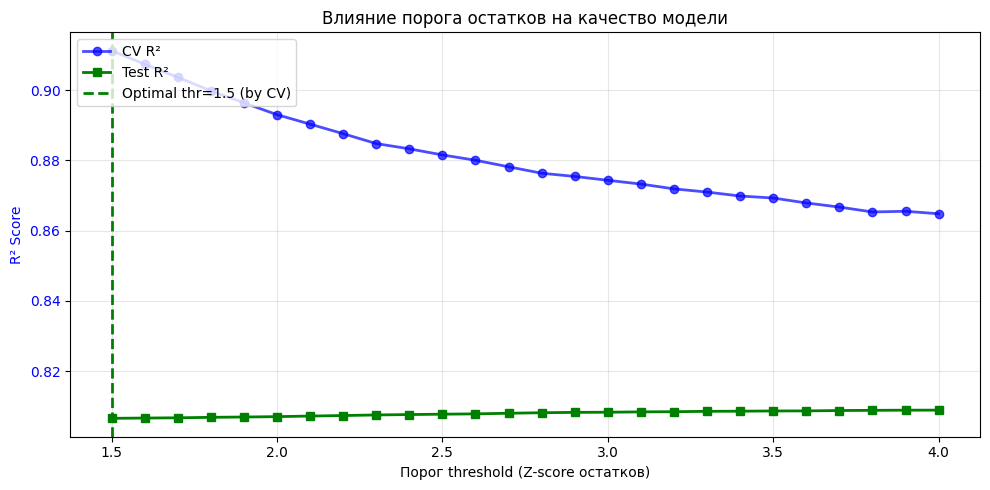

In [95]:
threshold_grid = np.round(np.arange(1.5, 4.1, 0.1), 1)
results_res = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0)) 
])

print("Подбор порога threshold для метода Residuals по CV R²...")
for thr in threshold_grid:
    y_pred_cv = cross_val_predict(pipe_base, X_train, y_train, cv=cv)
    outlier_mask = detect_outliers_residuals(y_train, y_pred_cv, threshold=thr)
    
    X_tr = X_train[~outlier_mask]
    y_tr = y_train[~outlier_mask]
    
    if len(X_tr) < 200:
        continue
        
    cv_scores = cross_val_score(pipe_base, X_tr, y_tr, cv=cv, scoring='r2')
    mean_cv_r2 = cv_scores.mean()
    
    pipe_test = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
    pipe_test.fit(X_tr, y_tr)
    test_r2 = r2_score(y_test, pipe_test.predict(X_test))
    
    results_res.append({
        'threshold': thr,
        'удалено': int(outlier_mask.sum()),
        'cv_r2': mean_cv_r2,
        'test_r2': test_r2
    })
    print(f"threshold={thr:.1f}: CV R²={mean_cv_r2:.4f} | Test R²={test_r2:.4f} | Удалено: {outlier_mask.sum()}")

df_res = pd.DataFrame(results_res)

best_idx = df_res['cv_r2'].idxmax()
best_thr = df_res.loc[best_idx, 'threshold']

print(f"\nОптимальный threshold по CV R²: {best_thr}")
print(f"Удалено строк: {df_res.loc[best_idx, 'удалено']}")
print(f"Test R² при этом threshold: {df_res.loc[best_idx, 'test_r2']:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_res['threshold'], df_res['cv_r2'], 'b-o', label='CV R²', linewidth=2, alpha=0.7)
ax1.plot(df_res['threshold'], df_res['test_r2'], 'g-s', label='Test R²', linewidth=2)
ax1.set_xlabel('Порог threshold (Z-score остатков)')
ax1.set_ylabel('R² Score', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)
ax1.axvline(best_thr, color='green', linestyle='--', linewidth=2, label=f'Optimal thr={best_thr} (by CV)')
ax1.legend(loc='upper left')
plt.title('Влияние порога остатков на качество модели')
plt.tight_layout()
plt.show()

In [96]:
y_pred_train_base = cross_val_predict(pipe_base, X_train, y_train, cv=cv)
outlier_mask_res = detect_outliers_residuals(y_train, y_pred_train_base, threshold=best_thr)

X_train_res = X_train[~outlier_mask_res]
y_train_res = y_train[~outlier_mask_res]

print(f"МЕТОД: Residuals Analysis")
print(f"Найдено выбросов: {outlier_mask_res.sum()} из {len(y_train)} ({outlier_mask_res.sum()/len(y_train)*100:.2f}%)")
print(f"Осталось наблюдений: {len(X_train_res)}")

scaler_res = StandardScaler()
X_train_res_scaled = scaler_res.fit_transform(X_train_res)
X_test_res_scaled = scaler_res.transform(X_test)


y_pred_linreg_res_test = model_linreg.predict(X_test_res_scaled)
y_pred_ridge_res_test = model_ridge.predict(X_test_res_scaled)

metrics_linreg_res = evaluate_model(y_test, y_pred_linreg_res_test, "Тест (Residuals)", "linreg_res")
metrics_ridge_res = evaluate_model(y_test, y_pred_ridge_res_test, "Тест (Residuals)", "ridge_res")

МЕТОД: Residuals Analysis
Найдено выбросов: 3950 из 54835 (7.20%)
Осталось наблюдений: 50885

МЕТРИКИ КАЧЕСТВА linreg_res:

Тест (Residuals):
  R² (коэффициент детерминации): 0.8067
  MSE (среднеквадратичная ошибка): 1.07
  RMSE (корень из MSE): 1.04
  MAE (средняя абсолютная ошибка): 0.69


МЕТРИКИ КАЧЕСТВА ridge_res:

Тест (Residuals):
  R² (коэффициент детерминации): 0.8069
  MSE (среднеквадратичная ошибка): 1.07
  RMSE (корень из MSE): 1.04
  MAE (средняя абсолютная ошибка): 0.69



In [97]:
results = []

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'Нет',
    'Train R²': train_linreg_metrics['r2'],
    'Test R²': test_linreg_metrics['r2'],
    'Test RMSE': test_linreg_metrics['rmse'],
    'Test MAE': test_linreg_metrics['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'Нет',
    'Train R²': train_ridge_metrics['r2'],
    'Test R²': test_ridge_metrics['r2'],
    'Test RMSE': test_ridge_metrics['rmse'],
    'Test MAE': test_ridge_metrics['mae']
})

results.append({
    'Модель': 'Linear Regression',
    'Детекция': 'Residuals',
    'Train R²': evaluate_model(y_train_res, model_linreg.predict(X_train_res_scaled), "Train", "")['r2'],
    'Test R²': metrics_linreg_res['r2'],
    'Test RMSE': metrics_linreg_res['rmse'],
    'Test MAE': metrics_linreg_res['mae']
})
results.append({
    'Модель': 'Ridge Regression',
    'Детекция': 'Residuals',
    'Train R²': evaluate_model(y_train_res, model_ridge.predict(X_train_res_scaled), "Train", "")['r2'],
    'Test R²': metrics_ridge_res['r2'],
    'Test RMSE': metrics_ridge_res['rmse'],
    'Test MAE': metrics_ridge_res['mae']
})


df_results = pd.DataFrame(results)
print(df_results[['Модель', 'Детекция', 'Train R²', 'Test R²', 'Test RMSE', 'Test MAE']].to_string(index=False))
best_idx = df_results['Test R²'].idxmax()
print(f"\n✓ Лучшая модель по Test R²: {df_results.loc[best_idx, 'Модель']} + {df_results.loc[best_idx, 'Детекция']} (R² = {df_results.loc[best_idx, 'Test R²']:.4f})")


МЕТРИКИ КАЧЕСТВА :

Train:
  R² (коэффициент детерминации): 0.9094
  MSE (среднеквадратичная ошибка): 0.45
  RMSE (корень из MSE): 0.67
  MAE (средняя абсолютная ошибка): 0.55


МЕТРИКИ КАЧЕСТВА :

Train:
  R² (коэффициент детерминации): 0.9095
  MSE (среднеквадратичная ошибка): 0.45
  RMSE (корень из MSE): 0.67
  MAE (средняя абсолютная ошибка): 0.55

           Модель  Детекция  Train R²  Test R²  Test RMSE  Test MAE
Linear Regression       Нет  0.818559 0.807690   1.033333  0.698088
 Ridge Regression       Нет  0.818551 0.807699   1.033309  0.698268
Linear Regression Residuals  0.909432 0.806738   1.035887  0.693997
 Ridge Regression Residuals  0.909463 0.806883   1.035498  0.693920

✓ Лучшая модель по Test R²: Ridge Regression + Нет (R² = 0.8077)


Эксперимент показал, что применение детекции выбросов по остаткам регрессии не привело к улучшению качества моделей на тестовой выборке. Несмотря на то, что параметр порога $threshold$ был подобран по максимуму на кросс-валидации, итоговые метрики на тесте оказались хуже, чем у моделей, которые обучались на исходных данных: для Ridge-регрессии $R^2$ снизился с $0.8077$ до $0.8069$, а $RMSE$ вырос с $1.0333$ до $1.0355$. Удаление $3950$ объектов (7.2% выборки) существенно увеличило Train $R^2$ (до 0.9094), что свидетельствует о переобучении модели на очищенной обучающей выборке и потере обобщающей способности.

## Пробуем в деревья

In [33]:
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

In [ ]:
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

params = {
    'n_estimators': [500, 1000, 2000, 3000],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda': [1, 3, 5, 10],
}

search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=params,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(
    X_train_scaled,
    y_train
)

In [ ]:
search.best_params_

{'subsample': 0.8,
 'reg_lambda': 10,
 'n_estimators': 2000,
 'max_depth': 7,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [ ]:
best_xgb = search.best_estimator_

y_xgb_train_pred = best_xgb.predict(X_train_scaled)
y_xgb_test_pred = best_xgb.predict(X_test_scaled)

In [ ]:
train_xgb_metrics = evaluate_model(
    y_train,
    y_xgb_train_pred,
    "Обучающая выборка",
    "xgboost"
)

test_xgb_metrics = evaluate_model(
    y_test,
    y_xgb_test_pred,
    "Тестовая выборка",
    "xgboost"
)

In [ ]:
model_package = {
    "model": best_xgb,
    "scaler": scaler
}

joblib.dump(
    model_package,
    "xgboost_with_scaler.pkl"
)

['xgboost_with_scaler.pkl']

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance


fig, ax = plt.subplots(figsize=(12, 5))

plot_importance(
    best_xgb,
    max_num_features=10,
    importance_type='gain',
    ax=ax
)

ax.set_title("Важность признаков модели XGBoost")
ax.set_xlabel("Вклад признака")


plt.tight_layout()
plt.show()

## Рекламный доход

In [37]:
xgb_model = joblib.load("models/xgboost_with_scaler.pkl")

In [110]:
y_xgb_test_pred = xgb_model['model'].predict(X_test_scaled)
y_linreg_test_pred = model_linreg.predict(X_test_scaled)

In [143]:
def mse_of_model(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

In [146]:
pred_mean_time = np.mean(np.expm1(y_xgb_test_pred))
# print(f"Предсказанное среднее время в игре: {pred_mean_time:.2f} секунд")

mean_ads = X_test['total_ads'].mean()
# print(f"Медианное количество показов рекламы: {mean_ads:.2f}")

REAL_MEAN_TIME = 8100  # time-spent на пользователя в месяце (Appmetrica, март 2026)
MONEY_PER_AD = 1.613  # выплата за одну рекламу в марте 2026 (в рублях)
REAL_MONTH_REVENUE = 1_274_175  # реальный доход от рекламы в марте 2026 (Appmetrica)
TOTAL_USERS = 69_100  # общее количество пользователей в марте 2026 (Appmetrica)

predicted_revenue = (mean_ads / REAL_MEAN_TIME) * pred_mean_time * MONEY_PER_AD * TOTAL_USERS

print(f"Предсказанный доход от рекламы: {predicted_revenue:.2f} рублей")
print(f"Реальный доход от рекламы: {REAL_MONTH_REVENUE:.2f} рублей")

print(f"Процент ошибки в предсказании дохода: {round(abs((predicted_revenue - REAL_MONTH_REVENUE) / REAL_MONTH_REVENUE * 100), 2)}%")

Предсказанный доход от рекламы: 1027429.28 рублей
Реальный доход от рекламы: 1274175.00 рублей
Процент ошибки в предсказании дохода: 19.37%
